In [1]:
# ===== GPU DIAGNOSTIC CELL =====
import torch


print(f"PyTorch: {torch.__version__} (CUDA {torch.version.cuda})")

if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    name = torch.cuda.get_device_name(0)
    cc = torch.cuda.get_device_capability(0)
    print(f"GPU Name: {name} | Compute Capability: {cc[0]}.{cc[1]}")
else:
    print("No CUDA GPU available")



# Test tensor on GPU
try:
    test_tensor = torch.tensor([1.0, 2.0]).cuda()
    print(f"✅ GPU tensor test successful: {test_tensor.device}")
except:
    print("❌ GPU tensor test failed")

# ===== FlashAttention 2 Diagnostic =====
print("=== FlashAttention 2 Diagnostics ===")
fa_ok = False
try:
    import flash_attn
    ver = getattr(flash_attn, "__version__", "unknown")
    print(f"flash-attn version: {ver}")
    try:
        major = int(str(ver).split(".")[0])
    except Exception:
        major = None
    if major and major >= 2:
        print("✅ FlashAttention 2 detected")
        fa_ok = True
    elif major:
        print("⚠️ FlashAttention < 2 detected; upgrade recommended")
    else:
        print("⚠️ Unable to parse flash-attn version; upgrade recommended")
    # Quick kernel import test (sanity check)
    try:
        from flash_attn import flash_attn_qkvpacked_func
        print("✅ Kernels import test passed")
    except Exception as e:
        print(f"⚠️ Kernel import test failed: {e}")
except Exception as e:
    print(f"❌ flash-attn not importable: {e}")

try:
    import transformers
    print(f"Transformers: {transformers.__version__}")
    print("Tip: For supported models, load with attn_implementation='flash_attention_2'")
except Exception as e:
    print(f"Transformers import error: {e}")

if not fa_ok:
    print("\nNext steps to get FlashAttention 2:")
    print("1) pip install --upgrade pip wheel setuptools")
    print("2) pip install -U flash-attn --no-build-isolation")
    print("If build fails, ensure CUDA matches PyTorch (CUDA", torch.version.cuda, ") and try:")
    print("   export CUDA_HOME=/usr/local/cuda-12.1  # adjust if needed")


PyTorch: 2.5.1+cu124 (CUDA 12.4)
Current GPU: 0
GPU memory: 23.7 GB
GPU Name: NVIDIA GeForce RTX 3090 | Compute Capability: 8.6
✅ GPU tensor test successful: cuda:0
=== FlashAttention 2 Diagnostics ===
flash-attn version: 2.8.2
✅ FlashAttention 2 detected
✅ Kernels import test passed


/home/zhuoyuan/miniconda3/envs/SmolLM_gec_project/lib/python3.11/site-packages/transformers/utils/hub.py:111: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Transformers: 4.53.0
Tip: For supported models, load with attn_implementation='flash_attention_2'


In [2]:
# Check if FlashAttention 2 is working fine with transformers integration.

import torch
from transformers import AutoModelForCausalLM

m = AutoModelForCausalLM.from_pretrained(
    "HuggingFaceTB/SmolLM-135M",
    attn_implementation="flash_attention_2",
    torch_dtype=torch.float16,
    device_map="auto",
)
print("Loaded with FA2:", getattr(m.config, "attn_implementation", getattr(m.config, "_attn_implementation", "unknown")))

# Cleanup
import gc
del m
gc.collect()
torch.cuda.empty_cache()

Loaded with FA2: flash_attention_2


In [2]:
# ===== Run Guide's Environment Check =====
from complete_packing_guide import check_your_setup
check_your_setup()



CHECKING YOUR ENVIRONMENT
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Compute Capability: 8.9
✅ Your GPU supports Flash Attention 2!
   - A6000: Yes
   - RTX 3090: Yes

TRL Version: 0.19.0
✅ padding_free flag available
⚠️ DataCollatorWithFlattening not available

flash-attn version: 2.8.2
✅ FlashAttention 2 is installed
✅ flash-attn kernels import test passed


**PLEASE DO NOT DISTRIBUTE!**

        ⚠️ The normalization layer used in the language model is RMSNorm which differs from the regular LayerNorm.

        ⚠️ The feedforward block used in the language model of this colab differs from a regular MLP block. Here we have 3 lnear layers insead of 2 linear layers. See Fig. 5 in https://docs.nvidia.com/deeplearning/transformer-engine/user-guide/examples/te_llama/tutorial_accelerate_hf_llama_with_te.html.


**Model** : SmolLM-135M can be found at [HuggingFace](https://huggingface.co/HuggingFaceTB/SmolLM-135M).

## 1. Setup [Helper Functions]

In [2]:
######################################################################################################################
############################################## DO NOT CHANGE[START] ##################################################
######################################################################################################################


# [Don't use. Rate limit issues.] Use gdown to get weights file(BareBones_SmolLM-135M.pt) at https://drive.google.com/file/d/1tY46FSJEhGYRrfKRQTjJ1Cc7q9psaKUU/view . gdown should be installed by default else use `pip install gdown`
# !gdown 1tY46FSJEhGYRrfKRQTjJ1Cc7q9psaKUU


# [Recommended]Use HF to download the weights
!git lfs install
!git clone https://huggingface.co/dsouzadaniel/C4AI_SMOLLM135
!mv C4AI_SMOLLM135/BareBones_SmolLM-135M.pt ./
!ls

Updated Git hooks.
Git LFS initialized.
fatal: destination path 'C4AI_SMOLLM135' already exists and is not an empty directory.
mv: cannot stat 'C4AI_SMOLLM135/BareBones_SmolLM-135M.pt': No such file or directory
BareBones_SmolLM-135M.pt
C4AI_SMOLLM135
Conversational_Format_Implementation_Plan.md
Copy_of_SFT_DPO_Practice_Original_20250621.ipynb
DPO_Variants_Implementation_Plan_Concise.md
DataCollator_Implementation_Plan.md
Hyperparameter_Search_Plan.md
Preference_Dataset_Implementation_Plan.md
Preference_Dataset_Implementation_Plan_Concise.md
README.md
SFT_DPO_Practice_20250729_Baseline_DataCollatorForCompletionOnlyLM.ipynb
SFT_DPO_Practice_20250729_Baseline_DataCollatorForCompletionOnlyLM_20250803.ipynb
SFT_DPO_Practice_20250729_Conversational.ipynb
SFT_DPO_Practice_Task1Finished_20250721.ipynb
SFT_DPO_Practice_Task1Finished_20250721_backup.ipynb
SFT_DPO_Practice_Task1Finished_20250726_backup.ipynb
SFT_DPO_Practice_v4_20250628.ipynb
SFT_Implementation_Plan_Concise.md
SFT_Implementation

# **Part 2: Teach SmolLM to do grammatical error correction**

The goal of this part is to train the SmolLM-135M model to perform grammatical error correction (GEC) using the Grammarly CoEdIT dataset. This [dataset](https://huggingface.co/datasets/grammarly/coedit), derived from the [CoEdIT project](https://arxiv.org/abs/2305.09857), provides a rich collection of text editing instructions and examples. The task involves several key steps that mimic conventional alignment processes:




## **2.1 Supervised Fine-Tuning (SFT) on Training Data [5 points]**

* Fine-tune the [SmolLM-135M model](https://huggingface.co/HuggingFaceTB/SmolLM-135M) using the CoEdIT dataset, which includes input sentences with grammatical errors and their corrected versions. Use the training GEC portion of the CoEdIT dataset to teach the model how to correct grammatical errors effectively.
* Calculate the BLEU score on the validation set to evaluate the model's performance in generating grammatically correct sentences. Ensure that this evaluation process is reusable for later comparisons.
* Search for an optimal set of hyperparameters, such as the learning rate. We provide an estimated BLEU score that you should aim to achieve after one epoch. However, you may achieve a better score by finding the most suitable hyperparameters. **Do not train for more than 3 epochs -- we do not expect extensive training time.**
* For Part 2, don't use additional libraries, if an imported library is missing, install it with **pip install**.

      💡 There are multiple ways to fine-tune an LLM with Hugging Face, and you should experiment with these approaches:

      1. Padding Approach
      In this method, all samples in a batch are padded to the same length. Simple, right? But there's a catch:

        ⚠️ If you don’t set up the PAD token correctly, your model might struggle to end completions smoothly.

      2. Packing Approach
      This method concatenates multiple samples into one long sequence. You can do this in two ways:

        Dataset level → Set packing=True when preparing your dataset.
        Batch level → Use DataCollatorWithFlattening or DataCollatorForCompletionOnlyLM.

        Batch-level packing requires Flash Attention v2, which means you’ll need a high-end GPU like Ampere (A100, A6000, RTX 4090) or Hopper (H100) series.
      A good resource for the 2 approaches above is Chapter 4 and 5 from this book: https://www.amazon.com/Hands-Fine-Tuning-Language-PyTorch-Hugging-ebook/dp/B0DV3Y1GMP?ref_=ast_author_dp.
      🎯 Optimizing for Best Results
      Regardless of the method you choose, tuning your training recipe is key to achieving a solid BLEU score. Pay close attention to:
        ✅ Learning rate
        ✅ Weight decay
        ✅ Batch size
        ✅ Sequence length
      Tweak these wisely, and you’ll be on your way to LLM fine-tuning success! 🚀

In [4]:
import torch
import torch.nn.functional as F
from torch import nn
import math
from transformers import AutoModelForCausalLM, AutoTokenizer

In [5]:
# ===== REPRODUCIBILITY SETUP =====
import random
import numpy as np
import torch

def set_seed(seed=42):
    """Set seed for reproducibility - fast version"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print(f"✅ Seeds set to {seed} for reproducibility")

# Set seed at the beginning
set_seed(42)

✅ Seeds set to 42 for reproducibility


In [6]:
# Helper functions for plotting training curves

import json
import matplotlib.pyplot as plt
import pandas as pd
import os

def load_training_history(checkpoint_path):
    """Load training history from trainer_state.json"""
    trainer_state_path = os.path.join(checkpoint_path, "trainer_state.json")
    with open(trainer_state_path, "r") as f:
        state = json.load(f)
    return state["log_history"]

def extract_losses(log_history):
    """Extract train and eval losses with steps into separate DataFrames"""
    train_data = []
    eval_data = []

    for entry in log_history:
        if "loss" in entry:
            train_data.append({
                "step": entry["step"],
                "loss": entry["loss"],
                "learning_rate": entry.get("learning_rate", 0),
                "epoch": entry.get("epoch", 0)
            })
        if "eval_loss" in entry:
            eval_data.append({
                "step": entry["step"],
                "eval_loss": entry["eval_loss"],
                "epoch": entry.get("epoch", 0)
            })

    return pd.DataFrame(train_data), pd.DataFrame(eval_data)

def plot_training_curves(train_df, eval_df, title="Training Curves", 
                        plot_loss=True, plot_lr=True, save_path=None):
    """
    Flexible plotting function
    
    Args:
        plot_loss (bool): Whether to plot loss curves
        plot_lr (bool): Whether to plot learning rate schedule
    """

    # Calculate subplot layout
    n_plots = sum([plot_loss, plot_lr])
    if n_plots == 0:
        print("❌ Error: Must plot at least one of loss or LR")
        return None

    fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))
    if n_plots == 1:
        axes = [axes]  # Make it iterable

    plot_idx = 0

    # Plot 1: Loss curves (if requested)
    if plot_loss:
        ax = axes[plot_idx]
        ax.plot(train_df["step"], train_df["loss"], 'b-', label='Training Loss', alpha=0.8)

        if not eval_df.empty:
            ax.plot(eval_df["step"], eval_df["eval_loss"], 'r-',
                    label='Validation Loss', marker='o', markersize=3)

            # Overfitting detection
            if len(eval_df) > 1:
                final_eval = eval_df["eval_loss"].iloc[-1]
                min_eval = eval_df["eval_loss"].min()
                if final_eval > min_eval * 1.1:
                    ax.axhline(y=min_eval, color='orange', linestyle='--', alpha=0.5,
                            label=f'Best Eval: {min_eval:.4f}')

        ax.set_xlabel('Steps')
        ax.set_ylabel('Loss')
        ax.set_title(f'{title} - Loss Curves')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # Plot 2: Learning rate (if requested)
    if plot_lr:
        ax = axes[plot_idx]
        if 'learning_rate' in train_df.columns and train_df['learning_rate'].max() > 0:
            ax.plot(train_df["step"], train_df["learning_rate"], 'g-', alpha=0.8)
            ax.set_xlabel('Steps')
            ax.set_ylabel('Learning Rate')
            ax.set_title(f'{title} - Learning Rate Schedule')
            ax.set_yscale('log')
        else:
            ax.text(0.5, 0.5, 'No Learning Rate Data',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title('Learning Rate Schedule')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Plot saved to {save_path}")

    plt.show()
    return fig

def plot_model_curves(checkpoint_path, title=None, plot_loss=True, plot_lr=True, save_path=None):
    """One-liner with flexible plotting options"""
    if title is None:
        title = os.path.basename(checkpoint_path.rstrip('/'))

    try:
        history = load_training_history(checkpoint_path)
        train_df, eval_df = extract_losses(history)
        return plot_training_curves(train_df, eval_df, title, plot_loss, plot_lr, save_path)
    except Exception as e:
        print(f"❌ Error plotting {checkpoint_path}: {str(e)}")
        return None

def plot_loss_comparison(checkpoint_paths, model_names=None, save_path=None):
    """Compare loss-only training curves for multiple models"""
    if model_names is None:
        model_names = [os.path.basename(path.rstrip('/')) for path in checkpoint_paths]

    plt.figure(figsize=(12, 6))

    for path, name in zip(checkpoint_paths, model_names):
        try:
            history = load_training_history(path)
            train_df, eval_df = extract_losses(history)

            plt.plot(train_df["step"], train_df["loss"],
                    label=f'{name} (Train)', alpha=0.8, linewidth=2)

            if not eval_df.empty:
                plt.plot(eval_df["step"], eval_df["eval_loss"],
                        label=f'{name} (Eval)', linestyle='--',
                        marker='o', markersize=3, alpha=0.8)
        except Exception as e:
            print(f"⚠️ Skipping {name}: {str(e)}")

    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Model Loss Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Comparison saved to {save_path}")

    plt.show()

"""
Usage Examples:

Option 1: Your preferred detailed approach:

# Load and extract
dpo_model_history = load_training_history("./dpo-smollm-model/checkpoint-1046")
dpo_model_train_df, dpo_model_eval_df = extract_losses(dpo_model_history)

# Plot with custom title
plot_training_curves(dpo_model_train_df, dpo_model_eval_df,
                    title="DPO Model", save_path="./dpo_curves.png")

Option 2: Your preferred one-liner:

# One line plotting (Full analysis (loss + LR))
plot_dpo_graph = plot_model_curves("./dpo-smollm-model/checkpoint-1046")

# With custom title and save
plot_model_curves("./dpo-smollm-model/checkpoint-1046",
                title="DPO Model", save_path="./dpo_curves.png")

# Just loss curves (cleaner for presentations)
plot_model_curves("./dpo-smollm-model/checkpoint-1046",
                title="DPO Loss Only", plot_lr=False)

# Just LR schedule (debugging convergence)
plot_model_curves("./dpo-smollm-model/checkpoint-1046",
                title="DPO LR Schedule", plot_loss=False)

Option 3: Compare all your models (just the loss curves):

# Compare all models at once
checkpoints = [
    "./sft-smollm-SFTpadding/checkpoint-2478",
    "./sft-smollm-packing/checkpoint-531",
    "./dpo-smollm-model/checkpoint-1046"
]
model_names = ["SFT Padding", "SFT Packing", "DPO"]

plot_loss_comparison(checkpoints, model_names, save_path="./all_models_comparison.png")


Recommended Workflow:

Now:

# 1. Analyze your current DPO
plot_model_curves("./dpo-smollm-model/checkpoint-1046",
                title="DPO Analysis", save_path="./dpo_current.png")

# 2. Compare all current models  
plot_loss_comparison(current_models, current_names,
                    save_path="./baseline_comparison.png")

For Each New Model:

# 3. When you train a new variant, immediately analyze it
plot_model_curves("./new-model/checkpoint-XXX",
                title="New Variant", save_path="./new_variant.png")

End of Part 3:

# 4. Final comprehensive comparison
plot_loss_comparison(all_variant_paths, all_variant_names,
                    save_path="./final_dpo_study.png")

"""

'\nUsage Examples:\n\nOption 1: Your preferred detailed approach:\n\n# Load and extract\ndpo_model_history = load_training_history("./dpo-smollm-model/checkpoint-1046")\ndpo_model_train_df, dpo_model_eval_df = extract_losses(dpo_model_history)\n\n# Plot with custom title\nplot_training_curves(dpo_model_train_df, dpo_model_eval_df,\n                    title="DPO Model", save_path="./dpo_curves.png")\n\nOption 2: Your preferred one-liner:\n\n# One line plotting (Full analysis (loss + LR))\nplot_dpo_graph = plot_model_curves("./dpo-smollm-model/checkpoint-1046")\n\n# With custom title and save\nplot_model_curves("./dpo-smollm-model/checkpoint-1046",\n                title="DPO Model", save_path="./dpo_curves.png")\n\n# Just loss curves (cleaner for presentations)\nplot_model_curves("./dpo-smollm-model/checkpoint-1046",\n                title="DPO Loss Only", plot_lr=False)\n\n# Just LR schedule (debugging convergence)\nplot_model_curves("./dpo-smollm-model/checkpoint-1046",\n            

In [7]:
from datasets import load_dataset

# Download the GEC data
full_train_ds = load_dataset("grammarly/coedit", split="train")
full_test_ds = load_dataset("grammarly/coedit", split="validation")

In [8]:
# Check dataset info
print(f"Train dataset size: {len(full_train_ds)}")
print(f"Test dataset size: {len(full_test_ds)}")
print(f"\nColumn names: {full_train_ds.column_names}")
print(f"\nFirst example:\n{full_train_ds[0]}")

# Look at a few more examples
print("\n" + "="*50 + "\n")
for i in range(3):
    print(f"Example {i+1}:")
    print(f"Task: {full_train_ds[i]['task']}")
    print(f"Source: {full_train_ds[i]['src']}")
    print(f"Target: {full_train_ds[i]['tgt']}")
    print("-"*30)

Train dataset size: 69071
Test dataset size: 1712

Column names: ['_id', 'task', 'src', 'tgt']

First example:
{'_id': '1', 'task': 'gec', 'src': 'Remove all grammatical errors from this text: For example, countries with a lot of deserts can terraform their desert to increase their habitable land and using irrigation to provide clean water to the desert.', 'tgt': 'For example, countries with a lot of deserts can transform their desert to increase their habitable land and use irrigation to provide clean water to the desert.'}


Example 1:
Task: gec
Source: Remove all grammatical errors from this text: For example, countries with a lot of deserts can terraform their desert to increase their habitable land and using irrigation to provide clean water to the desert.
Target: For example, countries with a lot of deserts can transform their desert to increase their habitable land and use irrigation to provide clean water to the desert.
------------------------------
Example 2:
Task: gec
Source

In [9]:
# Check all unique tasks in the dataset
from collections import Counter

tasks = [example['task'] for example in full_train_ds]
task_counts = Counter(tasks)
print("All tasks in the dataset:")
for task, count in task_counts.most_common():
    print(f"{task}: {count} examples")

All tasks in the dataset:
gec: 19823 examples
paraphrase: 15370 examples
simplification: 11440 examples
coherence: 10616 examples
neutralize: 10570 examples
clarity: 1252 examples


In [10]:
# TODO: Filter examples, keeping only GEC task


# Filter for GEC task only
train_ds = full_train_ds.filter(lambda example: example['task'] == 'gec')
test_ds = full_test_ds.filter(lambda example: example['task'] == 'gec')

print(f"GEC Train dataset size: {len(train_ds)}")
print(f"GEC Test dataset size: {len(test_ds)}")


GEC Train dataset size: 19823
GEC Test dataset size: 485


Expected number of train and test samples are 19823 and 485, respectively.

In [11]:
# Look at some GEC examples
print("\nGEC Examples:")
for i in range(min(5, len(train_ds))):
    print(f"\nExample {i+1}:")
    print(f"Input (with errors): {train_ds[i]['src']}")
    print(f"Corrected output: {train_ds[i]['tgt']}")


GEC Examples:

Example 1:
Input (with errors): Remove all grammatical errors from this text: For example, countries with a lot of deserts can terraform their desert to increase their habitable land and using irrigation to provide clean water to the desert.
Corrected output: For example, countries with a lot of deserts can transform their desert to increase their habitable land and use irrigation to provide clean water to the desert.

Example 2:
Input (with errors): Improve the grammaticality: As the number of people grows, the need of habitable environment is unquestionably essential.
Corrected output: As the number of people grows, the need for a habitable environment is unquestionably increasing.

Example 3:
Input (with errors): Improve the grammaticality of this sentence: Besides some technologically determinists that allow the development of biometric identification, this technology is also shaped by three social factors, namely, the desire of the society for safety, convenience a


Actual Training starts here

What's the thought process before I train any model? What is the roadmap in my mind? (See my journal, if I end up posting it)

In [11]:
# # Learn the AutoModelForCausalLM.from_pretrained() method's parameters
# help(AutoModelForCausalLM.from_pretrained) 

# # Learn the AutoModelForCausalLM.from_pretrained() method's **kwargsparameters
# import inspect
# from transformers import AutoModelForCausalLM

# # Inspect the source code 
# source = inspect.getsource(AutoModelForCausalLM.from_pretrained)
# print(source)

In [ ]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "HuggingFaceTB/SmolLM-135M"

# TODO: Load the model and the tokenizer from huggingface
model = AutoModelForCausalLM.from_pretrained( # download the model from huggingface and load it into the memory
    model_name,
    torch_dtype = torch.float32, 
    device_map = "auto",
    # Other available arguments: 
    # attn_implementation = "sdpa",
    # quantization_config = bnb_config, # Quantization Configuration， only use with LoRA
    # use_cache = True # Enable KV-cache
    # ...
    )


# Basic tokenizer setup
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Configure tokenizer

# Configure tokenizer with proper pad token
def setup_tokenizer_once(model, tokenizer):
    """
    One-time tokenizer setup for all SFT/DPO/IPO experiments.
    This ensures pad_token != eos_token to fix repetitive generation.
    Also adds [SEP] as a special token for reliable response separation.
    Maintains dtype consistency after adding tokens.
    """
    print("=== Setting up tokenizer ===")

    # Store the model's dtype for consistency
    model_dtype = model.dtype

    # Check if proper pad token already exists
    if tokenizer.pad_token_id is not None and tokenizer.pad_token_id != tokenizer.eos_token_id:
        print(f"✓ Pad token already properly configured: '{tokenizer.pad_token}' (ID: {tokenizer.pad_token_id})")
    else:
        # Add [PAD] token - this is the safest approach
        print("Adding [PAD] token to vocabulary...")
        num_added = tokenizer.add_special_tokens({'pad_token': '[PAD]'})
        print(f"Added {num_added} new tokens")

        # Resize model embeddings to match tokenizer
        print(f"Resizing model embeddings from {model.config.vocab_size} to {len(tokenizer)}")
        model.resize_token_embeddings(len(tokenizer))

        # Ensure embeddings stay in correct dtype
        model.get_input_embeddings().weight.data = model.get_input_embeddings().weight.data.to(model_dtype)
        if hasattr(model, 'lm_head'):
            model.lm_head.weight.data = model.lm_head.weight.data.to(model_dtype)

        # Initialize the new PAD embedding as zeros
        with torch.no_grad():
            model.get_input_embeddings().weight[-1].zero_()

    # Check if response separator token [SEP] already exists
    if '[SEP]' not in tokenizer.get_vocab():
        print("\nAdding [SEP] separator token...")
        old_vocab_size = len(tokenizer)

        # Add the special token
        if 'additional_special_tokens' in tokenizer.special_tokens_map:
            existing = tokenizer.special_tokens_map['additional_special_tokens']
            tokenizer.add_special_tokens({
                'additional_special_tokens': existing + ['[SEP]']
            })
        else:
            tokenizer.add_special_tokens({
                'additional_special_tokens': ['[SEP]']
            })

        # Resize if needed
        if len(tokenizer) > old_vocab_size:
            model.resize_token_embeddings(len(tokenizer))

            # Ensure embeddings stay in correct dtype
            model.get_input_embeddings().weight.data = model.get_input_embeddings().weight.data.to(model_dtype)
            if hasattr(model, 'lm_head'):
                model.lm_head.weight.data = model.lm_head.weight.data.to(model_dtype)

            print(f"Added [SEP] token, new vocab size: {len(tokenizer)}")

            # Initialize [SEP] embedding as mean of existing embeddings
            with torch.no_grad():
                mean_embedding = model.get_input_embeddings().weight[:-1].mean(dim=0)
                model.get_input_embeddings().weight[-1] = mean_embedding

    # Set padding side for causal LM
    tokenizer.padding_side = "left"

    # Update model config
    model.config.pad_token_id = tokenizer.pad_token_id

    # Verification
    sep_token_id = tokenizer.convert_tokens_to_ids('[SEP]')
    print(f"\n✓ Setup complete:")
    print(f"  - PAD token: '{tokenizer.pad_token}' (ID: {tokenizer.pad_token_id})")
    print(f"  - SEP token: '[SEP]' (ID: {sep_token_id})")
    print(f"  - EOS token: '{tokenizer.eos_token}' (ID: {tokenizer.eos_token_id})")
    print(f"  - PAD != EOS: {tokenizer.pad_token_id != tokenizer.eos_token_id} ✓")
    print(f"  - Model dtype: {model.dtype}")  # Added dtype check

    return model, tokenizer

# Apply the setup
model, tokenizer = setup_tokenizer_once(model, tokenizer)

=== Setting up tokenizer ===
Adding [PAD] token to vocabulary...
Added 1 new tokens
Resizing model embeddings from 49152 to 49153

Adding [SEP] separator token...
Added [SEP] token, new vocab size: 49154

✓ Setup complete:
  - PAD token: '[PAD]' (ID: 49152)
  - SEP token: '[SEP]' (ID: 49153)
  - EOS token: '<|endoftext|>' (ID: 0)
  - PAD != EOS: True ✓
  - Model dtype: torch.float32


In [13]:
print(f"Current special tokens: {tokenizer.special_tokens_map}")
print(f"Current vocab size: {len(tokenizer)}")

Current special tokens: {'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '[PAD]', 'additional_special_tokens': ['<|endoftext|>', '<|im_start|>', '<|im_end|>', '<repo_name>', '<reponame>', '<file_sep>', '<filename>', '<gh_stars>', '<issue_start>', '<issue_comment>', '<issue_closed>', '<jupyter_start>', '<jupyter_text>', '<jupyter_code>', '<jupyter_output>', '<jupyter_script>', '<empty_output>', '[SEP]']}
Current vocab size: 49154


In [14]:
# Check model and tokenizer info before training

# Check model info
print(f"Attention implementation: {model.config._attn_implementation}") # Expects 'sdpa' | 'eager' | 'flash_attention_2', final output is sdpa
print(f"Model type: {model.config.model_type}")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Vocab size: {model.config.vocab_size}")
print(f"Max position embeddings: {model.config.max_position_embeddings}")
print(f"Model dtype: {model.dtype}")
print(f"Device: {model.device}")

# Check tokenizer info
print(f"Tokenizer Vocab size: {tokenizer.vocab_size}")
print(f"Tokenizer Model max length: {tokenizer.model_max_length}")
print(f"Tokenizer Padding side: {tokenizer.padding_side}")
print(f"Tokenizer Pad token: {tokenizer.pad_token}")
print(f"Tokenizer Pad token id: {tokenizer.pad_token_id}")
print(f"Tokenizer BOS token: '{tokenizer.bos_token}' (ID: {tokenizer.bos_token_id})")
print(f"Tokenizer EOS token: '{tokenizer.eos_token}' (ID: {tokenizer.eos_token_id})")
print(f"Tokenizer PAD token: '{tokenizer.pad_token}' (ID: {tokenizer.pad_token_id})")
print(f"Tokenizer UNK token: '{tokenizer.unk_token}' (ID: {tokenizer.unk_token_id})")


# Quick functionality test
test_text = "Hello, world!"
inputs = tokenizer(test_text, return_tensors="pt").to(model.device)
with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=10)
print(f"Generation test: {tokenizer.decode(outputs[0])}")

Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


Attention implementation: sdpa
Model type: llama
Hidden size: 576
Vocab size: 49154
Max position embeddings: 2048
Model dtype: torch.float32
Device: cuda:0
Tokenizer Vocab size: 49152
Tokenizer Model max length: 1000000000000000019884624838656
Tokenizer Padding side: left
Tokenizer Pad token: [PAD]
Tokenizer Pad token id: 49152
Tokenizer BOS token: '<|endoftext|>' (ID: 0)
Tokenizer EOS token: '<|endoftext|>' (ID: 0)
Tokenizer PAD token: '[PAD]' (ID: 49152)
Tokenizer UNK token: '<|endoftext|>' (ID: 0)
Generation test: Hello, world!

**Step 1: Understanding What a


In [15]:
print(tokenizer.chat_template)

None


Because we didn't see an existing chat_template, so we hold off on the formatting the dataset into conversational format expecting SFTTrainer will handle it automatically (SFTTrainer can handle conversational format automatically by applying a chat_template). Instead, we try format like the following:

In [16]:
def format_text(example):
    """
      Since the instruction is already in src, we just need clear separation
      between the full instruction+incorrect_text and the corrected_text
    """
    return f"{example['src']}[SEP]{example['tgt']}{tokenizer.eos_token}"

# Apply formatting to datasets
def format_dataset(dataset):
    return dataset.map(lambda x: {"text": format_text(x)})

# Format the datasets
formatted_train_ds = format_dataset(train_ds)
formatted_test_ds = format_dataset(test_ds)

print("Sample formatted example:")
print(formatted_train_ds[0]["text"])
print(f"\nTrain dataset size: {len(formatted_train_ds)}")
print(f"Test dataset size: {len(formatted_test_ds)}")

Sample formatted example:
Remove all grammatical errors from this text: For example, countries with a lot of deserts can terraform their desert to increase their habitable land and using irrigation to provide clean water to the desert.[SEP]For example, countries with a lot of deserts can transform their desert to increase their habitable land and use irrigation to provide clean water to the desert.<|endoftext|>

Train dataset size: 19823
Test dataset size: 485


In [17]:
# Add this check to see if your [SEP] has correct spacing
sample_text = formatted_train_ds[0]["text"]
print(f"Sample text: {repr(sample_text)}")
print(f"Contains ' [SEP] ': {' [SEP] ' in sample_text}")
print(f"Contains '[SEP]': {'[SEP]' in sample_text}")
print(f"Contains ' [SEP]': {' [SEP]' in sample_text}")

Sample text: 'Remove all grammatical errors from this text: For example, countries with a lot of deserts can terraform their desert to increase their habitable land and using irrigation to provide clean water to the desert.[SEP]For example, countries with a lot of deserts can transform their desert to increase their habitable land and use irrigation to provide clean water to the desert.<|endoftext|>'
Contains ' [SEP] ': False
Contains '[SEP]': True
Contains ' [SEP]': False


In [18]:
# Check if separator was tokenized correctly 

sep_tokens = tokenizer.encode(" [SEP] ", add_special_tokens=False)
print(f"' [SEP] ' tokenizes to: {sep_tokens}")
print(f"Tokens: {[tokenizer.decode([t]) for t in sep_tokens]}")


sep_tokens = tokenizer.encode(" [SEP]", add_special_tokens=False)
print(f"' [SEP] ' tokenizes to: {sep_tokens}")
print(f"Tokens: {[tokenizer.decode([t]) for t in sep_tokens]}")


sep_tokens = tokenizer.encode("[SEP]", add_special_tokens=False)
print(f"' [SEP] ' tokenizes to: {sep_tokens}")
print(f"Tokens: {[tokenizer.decode([t]) for t in sep_tokens]}")

' [SEP] ' tokenizes to: [216, 49153, 216]
Tokens: [' ', '[SEP]', ' ']
' [SEP] ' tokenizes to: [216, 49153]
Tokens: [' ', '[SEP]']
' [SEP] ' tokenizes to: [49153]
Tokens: ['[SEP]']


# Padding Approach

In [21]:
# TRL - Transformer Reinforcement Learning -- https://huggingface.co/docs/trl/en/index
from trl import SFTConfig, SFTTrainer, DataCollatorForCompletionOnlyLM


# TODO: Run SFT

# Configure SFT training
training_args = SFTConfig(
    # === OUTPUT & LOGGING ===
    output_dir="./sft-smollm-SFTpadding",
    logging_dir="./logs",

    # === TRAINING PARAMETERS ===
    num_train_epochs=1,                            # Start with 1 (target BLEU 0.48)
    learning_rate=3e-5,                            # Conservative for fine-tuning
    lr_scheduler_type="cosine",                    # Better than linear for fine-tuning
    warmup_ratio=0.1,                              # 10% warmup steps
    weight_decay=0.01,                             # Standard L2 regularization
    seed=42,                                       # Training reproducibility
    data_seed=42,                                  # Data shuffling reproducibility

    # === BATCH SETTINGS ===
    per_device_train_batch_size=16,                 # SmolLM is small, can handle this: #Expriment shows: batch size = 8 takes about 7G vRAM, 16 takes 9vRAM, 24 takes 12.2
    per_device_eval_batch_size=16,                 # Larger for eval (no gradients)
    gradient_accumulation_steps=1,                 # Increase if OOM (effective batch = 8*1)

    # === MIXED PRECISION (Your smart approach!) ===
    bf16=torch.cuda.is_bf16_supported(),           # Use bf16 if available (A100, etc)
    fp16=not torch.cuda.is_bf16_supported(),       # Fallback to fp16

    # === MEMORY OPTIMIZATIONS ===
    gradient_checkpointing=False,                  # Enable if OOM (SmolLM likely won't need)
    optim="adamw_torch",                          # Standard optimizer (model is small)


    # === DATASET CONFIGURATION ===
    max_seq_length=256,                                # DEPRECATED: Will be removed in v0.20.0, but still works
    packing=False,                                     # Disable sequence packing - simpler, better for debugging
    remove_unused_columns=True,                        # Clean up dataset columns not needed for training
    dataset_text_field="text",                         # Field name from formatting

    # === SAVING STRATEGY ===
    save_strategy="epoch",                             # Save checkpoint after each epoch
    save_total_limit=2,                                # Keep only 2 most recent checkpoints (save disk space)
    # load_best_model_at_end=True,                       # Load best checkpoint at end (based on eval metric), comment out this line to see logging per N steps
    # metric_for_best_model="eval_loss",
    # === EVALUATION STRATEGY (CRITICAL FIX!) ===
    # eval_strategy="no",                             # we set "no" here to output logging per N steps. If = "epoch" then means evaluate after each epoch - MUST match save_strategy!
    eval_strategy="steps",
    eval_steps=100,
    
    # === LOGGING ===
    logging_steps=100,
    # logging_strategy="steps",                                  # Log every 100 steps (good frequency for monitoring)
    logging_first_step=True,                           # Log the very first step (useful for debugging)
    report_to="none"                                   # Disable external logging (wandb, tensorboard)
    
)


# Create the data collator
data_collator = DataCollatorForCompletionOnlyLM(
    response_template="[SEP]",  # IMPORTANT: vocabulary only has "[SEP]", don't set it to " [SEP] "
    tokenizer=tokenizer,
    mlm=False  # We're doing causal LM, not masked LM
)

# Initialize SFT trainer
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=formatted_train_ds,
    eval_dataset=formatted_test_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
)

print("Starting SFT training...")
trainer.train()
print("SFT training completed!")
trainer.save_model("./sft-smollm-SFTpadding-model")
tokenizer.save_pretrained("./sft-smollm-SFTpadding-model")

Starting SFT training...


Step,Training Loss,Validation Loss
100,0.993200,1.071406
200,0.427200,1.014422
300,0.402800,0.964126
400,0.394900,0.951128
500,0.368000,0.935904
600,0.349900,0.931381
700,0.362600,0.921890
800,0.352600,0.923739
900,0.368100,0.915015
1000,0.359700,0.913810


SFT training completed!


('./sft-smollm-SFTpadding-model/tokenizer_config.json',
 './sft-smollm-SFTpadding-model/special_tokens_map.json',
 './sft-smollm-SFTpadding-model/vocab.json',
 './sft-smollm-SFTpadding-model/merges.txt',
 './sft-smollm-SFTpadding-model/added_tokens.json',
 './sft-smollm-SFTpadding-model/tokenizer.json')

In [ ]:
# === DEBUG THE DATA COLLATOR BEHAVIOR: make sure the loss is calculated (not 0% loss) and is only computed for the response part for DataCollatorForCompletionOnlyLM===
def debug_data_collator_behavior(trainer, num_batches=3):

    """Check what the data collator is actually producing"""
    print("🔍 DEBUGGING DATA COLLATOR BEHAVIOR")
    print("=" * 50)
    
    dataloader = trainer.get_train_dataloader()
    
    for batch_idx, batch in enumerate(dataloader):
        if batch_idx >= num_batches:
            break
            
        print(f"\n📦 Batch {batch_idx + 1}:")
        print(f"Batch size: {batch['input_ids'].shape[0]}")
        print(f"Sequence length: {batch['input_ids'].shape[1]}")
        
        # Check labels
        labels = batch['labels']
        
        for i in range(min(2, batch['input_ids'].shape[0])):  # Check first 2 examples in batch
            input_ids = batch['input_ids'][i]
            example_labels = labels[i]
            
            # Count non-ignored tokens (labels != -100)
            valid_labels = (example_labels != -100).sum().item()
            total_tokens = len(example_labels)
            
            print(f"\nExample {i+1} in batch:")
            print(f"Total tokens: {total_tokens}")
            print(f"Tokens used for loss (not -100): {valid_labels}")
            print(f"Tokens ignored for loss: {total_tokens - valid_labels}")
            print(f"Percentage used for loss: {valid_labels/total_tokens*100:.1f}%")
            
            # Decode the sequence
            text = tokenizer.decode(input_ids, skip_special_tokens=True)
            print(f"Decoded text: {text[:100]}...")
            
                
            # Show where the valid labels start (response part)
            if valid_labels > 0:
                first_valid_idx = (example_labels != -100).nonzero()[0].item()
                response_start = tokenizer.decode(input_ids[first_valid_idx:first_valid_idx+10])
                print(f"Response starts with: '{response_start}...'")
            
        print("-" * 40)

# Run after creating trainer but before training
debug_data_collator_behavior(trainer, num_batches=2)

🔍 DEBUGGING DATA COLLATOR BEHAVIOR

📦 Batch 1:
Batch size: 16
Sequence length: 83

Example 1 in batch:
Total tokens: 83
Tokens used for loss (not -100): 29
Tokens ignored for loss: 54
Percentage used for loss: 34.9%
Decoded text: Fix errors in this text: On the contrary, diverting public spending on other areas of the country's ...
Response starts with: 'On the contrary, diverting public spending on the...'

Example 2 in batch:
Total tokens: 83
Tokens used for loss (not -100): 27
Tokens ignored for loss: 56
Percentage used for loss: 32.5%
Decoded text: Improve the grammaticality of this text: Because I was so sure Abul kaka and Noman will prefer Arich...
Response starts with: 'Because I was so sure Abul kaka and...'
----------------------------------------

📦 Batch 2:
Batch size: 16
Sequence length: 80

Example 1 in batch:
Total tokens: 80
Tokens used for loss (not -100): 27
Tokens ignored for loss: 53
Percentage used for loss: 33.8%
Decoded text: Fix all grammatical errors: Secondly, 

In [24]:
# Quick test if your model works properly
def format_inference_text(text: str) -> str:
    """Format input for inference to match training format"""
    return f"{text}[SEP]"


# Example of how to run inference on a single example
text = "Fix grammatically: I likes turtles"
formatted_input = format_inference_text(text)
inputs = tokenizer(formatted_input, return_tensors="pt", padding=True, truncation=True, max_length=128)
inputs = {k: v.to(model.device) for k, v in inputs.items()}  # Move all input tensors to GPU
outputs = model.generate(
    **inputs,
    max_new_tokens=128, 
    # temperature=0.0,
    do_sample=False, # Deterministic output (removed temperature warning)
    pad_token_id=tokenizer.pad_token_id)


print(f"Input: {text}")
print(f"Full generated: {tokenizer.decode(outputs[0])}")



# Added Logic to extract the only the correction from the full output
print("--------------------------------")
print("--------------------------------")
print("Extracting the correction from the full output")
print("--------------------------------")
print("--------------------------------")

# Decode and extract the correction
full_output = tokenizer.decode(outputs[0], skip_special_tokens=False)

# Remove only the EOS token manually
full_output = full_output.replace(tokenizer.eos_token, "").strip()

# Also remove PAD tokens if present so the input looks clean
if tokenizer.pad_token:
    full_output = full_output.replace(tokenizer.pad_token, "").strip()

# Split by [SEP] to get just the correction
if "[SEP]" in full_output:
    input_part, correction = full_output.split("[SEP]", 1)
    print(f"Input: {text}")
    print(f"Correction: {correction.strip()}")
else:
    print(f"Full output: {full_output}")

Input: Fix grammatically: I likes turtles
Full generated: Fix grammatically: I likes turtles[SEP]I like turtles.<|endoftext|>
--------------------------------
--------------------------------
Extracting the correction from the full output
--------------------------------
--------------------------------
Input: Fix grammatically: I likes turtles
Correction: I like turtles.


Expected output: I like turtles.

In [23]:
# Helper Function: evaluate_model(model, tokenizer, ds) function with intermediate BLEU score calculation

import evaluate
from tqdm import tqdm

# BLEU Score
def evaluate_model(model, tokenizer, ds):
    """
    Evaluate model on the test dataset.
    
    Args:
        model: The fine-tuned model
        tokenizer: The tokenizer
        ds: The UNFORMATTED test dataset (with 'src' and 'tgt' fields)
    """
    # TODO - compute and call preds and targets for the bleu.compute in the following.
    preds = []
    targets = []

    # Put model in eval mode
    model.eval()

    # Use enumerate to get index for progress tracking
    for i, example in enumerate(tqdm(ds, desc="Evaluating")):
        # Get input from 'src' field
        input_text = example['src']

        # Format exactly as in training
        formatted_input = f"{input_text}[SEP]"

        # Tokenize
        inputs = tokenizer(
            formatted_input,
            return_tensors="pt",
            truncation=True,
            max_length=256
        ).to(model.device)

        # Generate prediction
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=128,
                do_sample=False,  # Deterministic
                pad_token_id=tokenizer.pad_token_id,  # Avoid warning
                eos_token_id=tokenizer.eos_token_id   # Know when to stop
            )

        # Decode the output - DON'T skip special tokens, we need [SEP]!
        full_output = tokenizer.decode(outputs[0], skip_special_tokens=False)

        # Remove only EOS and PAD tokens manually
        full_output = full_output.replace(tokenizer.eos_token, "").strip()
        if tokenizer.pad_token:
            full_output = full_output.replace(tokenizer.pad_token, "").strip()

        # Extract prediction after [SEP]
        if "[SEP]" in full_output:
            _, prediction = full_output.split("[SEP]", 1)
            prediction = prediction.strip()
        else:
            # Fallback if model didn't learn to use [SEP] properly
            print(f"Warning: No [SEP] found in: {full_output[:50]}...")
            prediction = full_output.replace(formatted_input, "").strip()

        # Get ground truth from 'tgt' field
        target = example['tgt'].strip()

        # Add to lists
        preds.append(prediction)
        targets.append([target])  # BLEU expects list of lists

        # Print progress with intermediate BLEU every 100 samples
        if (i + 1) % 100 == 0:
            # Calculate intermediate BLEU score
            bleu = evaluate.load("bleu")
            intermediate_score = bleu.compute(
                predictions=preds,
                references=targets
            )["bleu"]
            print(f"\nProcessed {i + 1}/{len(ds)} samples... BLEU: {intermediate_score:.4f}")

    # Put model back in train mode
    model.train()

    bleu = evaluate.load("bleu")
    results = bleu.compute(predictions=preds, references=targets)
    return results["bleu"]

In [24]:
# ===== Helper Functions: BLEU SCORE PERSISTENCE =====
""" 
Since we don't want to re-evaluate the model to get BLEU scores every time we reload the kernel
we save the BLEU scores to a JSON file 
"""

import json
import os

def save_bleu_score(score_name, score_value, filename="bleu_results.json"):
    """Save a single BLEU score to JSON file"""
    # Load existing scores or create new dict
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            scores = json.load(f)
    else:
        scores = {}

    # Update with new score
    scores[score_name] = score_value

    # Save back to file
    with open(filename, 'w') as f:
        json.dump(scores, f, indent=2)
    print(f"✅ {score_name} = {score_value:.4f} saved")

def load_bleu_scores(filename="bleu_results.json"):
    """Load all BLEU scores into variables"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            scores = json.load(f)
        print(f"✅ BLEU scores loaded from {filename}")
        return scores
    else:
        print(f"❌ {filename} not found")
        return {}


In [27]:
# TODO: Evaluate model, use the function given above
print("Starting evaluation with reduced output...")
sft_padding_bleu_score = evaluate_model(model, tokenizer, test_ds)  # Use test_ds!
save_bleu_score("sft_padding_bleu_score", sft_padding_bleu_score)

print(f"BLEU Score: {sft_padding_bleu_score:.4f}")
print(f"Expected BLEU score after 1 epoch SFT is ~ 0.48")


Starting evaluation with reduced output...


Evaluating:  21%|██        | 100/485 [02:41<13:51,  2.16s/it]


Processed 100/485 samples... BLEU: 0.4646


Evaluating:  41%|████      | 200/485 [05:02<07:09,  1.51s/it]


Processed 200/485 samples... BLEU: 0.4709


...


Processed 300/485 samples... BLEU: 0.4775


Evaluating:  82%|████████▏ | 400/485 [09:35<04:04,  2.87s/it]


Processed 400/485 samples... BLEU: 0.4829


Evaluating: 100%|██████████| 485/485 [11:50<00:00,  1.47s/it]


✅ sft_padding_bleu_score = 0.4850 saved
BLEU Score: 0.4850
Expected BLEU score after 1 epoch SFT is ~ 0.48


Expected BLEU score after 1 epoch SFT is ~ 0.48.


In [ ]:
# (To be deleted later) Add this debug cell right after your inference test
print("=== DEBUGGING MODEL OUTPUT ===")

# Check tokenizer encoding
test_input = "Fix grammatically: I likes turtles[SEP]"
print(f"Input text: {test_input}")

# Tokenize and decode to see if there's corruption
tokens = tokenizer(test_input, return_tensors="pt")
print(f"\nTokenized: {tokens['input_ids'][0].tolist()}")
print(f"Decoded back: {tokenizer.decode(tokens['input_ids'][0])}")

# # Check specific tokens
# i_token = tokenizer.encode("I", add_special_tokens=False)
# one_token = tokenizer.encode("1", add_special_tokens=False)
# print(f"\nToken for 'I': {i_token}")
# print(f"Token for '1': {one_token}")

# Test a few more examples
test_examples = [
    "Fix grammatically: I am happy",
    "Fix grammatically: She don't know",
    "Fix grammatically: The cat are sleeping"
]

print("\n=== Testing more examples ===")
for example in test_examples:
    formatted_input = f"{example}[SEP]"
    inputs = tokenizer(formatted_input, return_tensors="pt", truncation=True, max_length=256)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=50,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=False)
    
    # Remove only EOS and PAD tokens manually
    full_output = full_output.replace(tokenizer.eos_token, "").strip()
    if tokenizer.pad_token:
        full_output = full_output.replace(tokenizer.pad_token, "").strip()

    if "[SEP]" in full_output:
        _, correction = full_output.split("[SEP]", 1)
        print(f"{example} → {correction.strip()}")

=== DEBUGGING MODEL OUTPUT ===
Input text: Fix grammatically: I likes turtles[SEP]

Tokenized: [54, 1088, 21813, 947, 42, 339, 15044, 16304, 49153]
Decoded back: Fix grammatically: I likes turtles[SEP]

Token for 'I': [57]
Token for '1': [33]

=== Testing more examples ===
Fix grammatically: I am happy → I am happy.
Fix grammatically: She don't know → She doesn't know.
Fix grammatically: The cat are sleeping → The cat is sleeping.


Now we want to compare with the BLEU score of the base model before fine-tuning at all to see the improvement.

In [29]:
# Load the original base model (not fine-tuned)
from transformers import AutoModelForCausalLM, AutoTokenizer

print("Loading base model for baseline evaluation...")
base_model = AutoModelForCausalLM.from_pretrained(
    "HuggingFaceTB/SmolLM-135M",
    torch_dtype=torch.float32,
    device_map="auto"
)

# Use original tokenizer settings (don't change padding_side!)
base_tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM-135M")
base_tokenizer.pad_token = base_tokenizer.eos_token
base_model.config.pad_token_id = base_tokenizer.pad_token_id

# Evaluate base model on test set
print("\nEvaluating BASE model on test set (485 samples)...")
print("This will take ~15-20 minutes...")
baseline_bleu = evaluate_model(base_model, base_tokenizer, test_ds)
save_bleu_score("baseline_bleu", baseline_bleu)

# Print comparison
print("\n" + "="*60)
print("RESULTS COMPARISON:")
print("="*60)
print(f"Baseline BLEU (no training):  {baseline_bleu:.4f}")
print(f"SFT BLEU (padding approach):  {sft_padding_bleu_score:.4f}")

# Calculate improvement
improvement = sft_padding_bleu_score - baseline_bleu
if baseline_bleu > 0:
    improvement_percent = (improvement / baseline_bleu) * 100
    print(f"Improvement:                  +{improvement:.4f} (+{improvement_percent:.1f}%)")
else:
    print(f"Improvement:                  +{improvement:.4f} (baseline was ~0)")
print("="*60)

# Clean up memory
del base_model, base_tokenizer
torch.cuda.empty_cache()
print("Base model cleaned from memory.")

Loading base model for baseline evaluation...

Evaluating BASE model on test set (485 samples)...
This will take ~15-20 minutes...


Evaluating:  21%|██        | 100/485 [04:34<21:24,  3.34s/it]


Processed 100/485 samples... BLEU: 0.0574


Evaluating:  41%|████      | 200/485 [09:08<16:07,  3.40s/it]


Processed 200/485 samples... BLEU: 0.0551


...


Processed 300/485 samples... BLEU: 0.0471


Evaluating:  82%|████████▏ | 400/485 [18:13<04:10,  2.95s/it]


Processed 400/485 samples... BLEU: 0.0503


Evaluating: 100%|██████████| 485/485 [22:08<00:00,  2.74s/it]


✅ baseline_bleu = 0.0513 saved

RESULTS COMPARISON:
Baseline BLEU (no training):  0.0513
SFT BLEU (padding approach):  0.4850
Improvement:                  +0.4337 (+845.2%)
Base model cleaned from memory.


## Packing Approach



In [ ]:
# Clean previous model and trainer from memory
print("Cleaning previous model from memory...")

import gc
# Delete model and trainer objects to free GPU memory
if 'model' in globals():
    del model
if 'tokenizer' in globals():
    del tokenizer
if 'trainer' in globals():
    del trainer
gc.collect()
torch.cuda.empty_cache()

# Reload fresh base model for packing experiment
print("Loading fresh base model for packing experiment...")
model = AutoModelForCausalLM.from_pretrained(
    "HuggingFaceTB/SmolLM-135M",
    torch_dtype=torch.float32,
    device_map="auto"
)

# Reconfigure tokenizer (same as before)
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM-135M")
model, tokenizer = setup_tokenizer_once(model, tokenizer)

# Configure SFT training with PACKING
training_args_packing = SFTConfig(
    # === OUTPUT & LOGGING ===
    output_dir="./sft-smollm-packing",
    logging_dir="./logs-packing",

    # === TRAINING PARAMETERS ===
    num_train_epochs=1,
    learning_rate=3e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    weight_decay=0.01,
    seed=42,                                       # Training reproducibility
    data_seed=42,                                  # Data shuffling reproducibility
    
    # === BATCH SETTINGS ===
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,

    # === MIXED PRECISION ===
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),

    # === MEMORY OPTIMIZATIONS ===
    gradient_checkpointing=False,
    optim="adamw_torch",

    # === DATASET CONFIGURATION (KEY DIFFERENCE!) ===
    max_seq_length=256,
    packing=True,                           # ENABLE PACKING!
    dataset_text_field="text",
    remove_unused_columns=True,

    # === SAVING & EVALUATION ===
    save_strategy="epoch",
    save_total_limit=2,
    # eval_strategy="no",                     # No eval during training for clean logs
    eval_strategy="steps",
    eval_steps=50,  # Evaluate every 200 steps
    
    # === LOGGING ===
    logging_steps=50,
    logging_first_step=True,
    report_to="none"
)

# Initialize SFT trainer with packing
trainer_packing = SFTTrainer(
    model=model,
    args=training_args_packing,
    train_dataset=formatted_train_ds,       # Same training data
    eval_dataset=formatted_test_ds,         # Same eval data
    processing_class=tokenizer,
)

print("Starting SFT training with PACKING...")
trainer_packing.train()
print("SFT packing training completed!")

# Save the packing model
trainer_packing.save_model("./sft-smollm-SFTpacking-model")
print("Packing model saved!")
tokenizer.save_pretrained("./sft-smollm-SFTpacking-model") 

Cleaning previous model from memory...
Loading fresh base model for packing experiment...
=== Setting up tokenizer ===
Adding [PAD] token to vocabulary...
Added 1 new tokens
Resizing model embeddings from 49152 to 49153

Adding [SEP] separator token...
Added [SEP] token, new vocab size: 49154

✓ Setup complete:
  - PAD token: '[PAD]' (ID: 49152)
  - SEP token: '[SEP]' (ID: 49153)
  - EOS token: '<|endoftext|>' (ID: 0)
  - PAD != EOS: True ✓


/home/zhuoyuan/miniconda3/envs/sft_dpo_env/lib/python3.11/site-packages/trl/trainer/sft_trainer.py:404: UserWarning: Padding-free training is enabled, but the attention implementation is not set to 'flash_attention_2'. Padding-free training flattens batches into a single sequence, and 'flash_attention_2' is the only known attention mechanism that reliably supports this. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation='flash_attention_2'` in the model configuration, or verify that your attention mechanism can handle flattened sequences.
  warnings.warn(
/home/zhuoyuan/miniconda3/envs/sft_dpo_env/lib/python3.11/site-packages/trl/trainer/sft_trainer.py:450: UserWarning: You are using packing, but the attention implementation is not set to 'flash_attention_2'. Packing flattens batches into a single sequence, and 'flash_attention_2' is the only known attention mechanism that reliably supports this. Using other implementations ma

Starting SFT training with PACKING...


Step,Training Loss,Validation Loss
50,2.626100,4.532939
100,2.057900,4.552239
150,1.941100,4.538868
200,1.884700,4.494037
250,1.858900,4.515034
300,1.815000,4.515196
350,1.794000,4.506124
400,1.804900,4.504822
450,1.782900,4.504153
500,1.772300,4.504959


/home/zhuoyuan/miniconda3/envs/sft_dpo_env/lib/python3.11/site-packages/transformers/trainer.py:4091: UserWarning: mtime may not be reliable on this filesystem, falling back to numerical ordering
  warnings.warn("mtime may not be reliable on this filesystem, falling back to numerical ordering")


SFT packing training completed!
Packing model saved!


('./sft-smollm-SFTpacking-model/tokenizer_config.json',
 './sft-smollm-SFTpacking-model/special_tokens_map.json',
 './sft-smollm-SFTpacking-model/vocab.json',
 './sft-smollm-SFTpacking-model/merges.txt',
 './sft-smollm-SFTpacking-model/added_tokens.json',
 './sft-smollm-SFTpacking-model/tokenizer.json')

In [31]:
from trl import SFTConfig, SFTTrainer

For packing approach, it's worth noting that when we increase per_device_train_batch_size=8 to per_device_train_batch_size=16, the BLEU score decreased significantly if we are using DataCollatorForCompletionOnly approach. (The output of trying per_device_train_batch_size=16 is neglected here to save space) 

In [ ]:
# Evaluate the packing model
# Option 1: Evaluate the model directly from the model object
print("Evaluating SFT model trained with PACKING...")
sft_packing_bleu_score = evaluate_model(model, tokenizer, test_ds)
save_bleu_score("sft_packing_bleu_score", sft_packing_bleu_score)


# # Option 2: Explicit evaluation approach if prefer loading the model from the saved checkpoint to be more explicit
# print("Loading and evaluating SFT packing model...")
# sft_packing_model = AutoModelForCausalLM.from_pretrained(
#     "./sft-smollm-SFTpacking-model",
#     torch_dtype=torch.float32,
#     device_map="auto"
# )
# sft_packing_model.config.pad_token_id = tokenizer.pad_token_id

# # Now it's crystal clear which model we're evaluating
# sft_packing_bleu_score = evaluate_model(sft_packing_model, tokenizer, test_ds)
# save_bleu_score("sft_packing_bleu_score", sft_packing_bleu_score)

Evaluating SFT model trained with PACKING...


Evaluating:  21%|██        | 100/485 [02:48<07:56,  1.24s/it]


Processed 100/485 samples... BLEU: 0.4144


Evaluating:  41%|████      | 200/485 [05:19<05:34,  1.17s/it]


Processed 200/485 samples... BLEU: 0.4051


...


Processed 300/485 samples... BLEU: 0.4188


Evaluating:  82%|████████▏ | 400/485 [10:03<03:58,  2.81s/it]


Processed 400/485 samples... BLEU: 0.4248


Evaluating: 100%|██████████| 485/485 [12:21<00:00,  1.53s/it]


✅ sft_packing_bleu_score = 0.4239 saved


In [35]:
scores = load_bleu_scores()
baseline_bleu = scores.get("baseline_bleu", 0.0)
sft_padding_bleu_score = scores.get("sft_padding_bleu_score", 0.0)
sft_packing_bleu_score = scores.get("sft_packing_bleu_score", 0.0)

# Final comparison of all models
print("\n" + "="*70)
print("COMPLETE RESULTS COMPARISON:")
print("="*70)
print(f"Baseline BLEU (no training):     {baseline_bleu:.4f}")
print(f"SFT BLEU (padding approach):     {sft_padding_bleu_score:.4f}")
print(f"SFT BLEU (packing approach):     {sft_packing_bleu_score:.4f}")
print("-" * 70)

# Calculate improvements
padding_improvement = sft_padding_bleu_score - baseline_bleu
packing_improvement = sft_packing_bleu_score - baseline_bleu
packing_vs_padding = sft_packing_bleu_score - sft_padding_bleu_score

print(f"Padding improvement over baseline: +{padding_improvement:.4f}")
print(f"Packing improvement over baseline: +{packing_improvement:.4f}")
print(f"Packing vs Padding difference:    {packing_vs_padding:+.4f}")

if abs(packing_vs_padding) < 0.01:
    print("→ Similar performance between packing and padding")
elif packing_vs_padding > 0:
    print("→ Packing approach performs better")
else:
    print("→ Padding approach performs better")
print("="*70)

✅ BLEU scores loaded from bleu_results.json

COMPLETE RESULTS COMPARISON:
Baseline BLEU (no training):     0.0513
SFT BLEU (padding approach):     0.4850
SFT BLEU (packing approach):     0.4239
----------------------------------------------------------------------
Padding improvement over baseline: +0.4337
Packing improvement over baseline: +0.3726
Packing vs Padding difference:    -0.0611
→ Padding approach performs better


In [36]:
import gc
# Delete model and trainer objects to free GPU memory
if 'model' in globals():
    del model
if 'tokenizer' in globals():
    del tokenizer
if 'trainer_packing' in globals():
    del trainer_packing

# Force garbage collection and clear GPU cache
gc.collect()
torch.cuda.empty_cache()

print("✅ Memory cleaned for Part 2.2")

✅ Memory cleaned for Part 2.2


# Packing Approach 2: Batch-level Packing

In [20]:
# ===== PACKING APPROACH 2: Batch-Level Packing =====
print("Cleaning previous model from memory (batch-level)...")

import gc, torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from trl import SFTConfig, SFTTrainer

# Free previous state
if 'model' in globals():
    del model
if 'tokenizer' in globals():
    del tokenizer
if 'trainer' in globals():
    del trainer

gc.collect()
torch.cuda.empty_cache()

# === Load fresh base model for batch-level packing ===
print("Loading fresh base model for batch-level packing...")

try:
    model = AutoModelForCausalLM.from_pretrained(
        "HuggingFaceTB/SmolLM-135M",
        attn_implementation="flash_attention_2",
        torch_dtype=torch.float32,
        device_map="auto",
    )
    print("✅ Loaded with FlashAttention 2")
except Exception as e:
    print("⚠️ FA2 load failed, falling back to standard attention:", e)
    model = AutoModelForCausalLM.from_pretrained(
        "HuggingFaceTB/SmolLM-135M",
        torch_dtype=torch.float32,
        device_map="auto",
    )

# === Tokenizer (use your project's setup helper) ===
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM-135M")
model, tokenizer = setup_tokenizer_once(model, tokenizer)

# === Configure SFT training (batch-level) ===


# === SHARED TRAINING ARGS (used by both methods:padding_free and Flattening) ===

# Difference between methods:
# - padding_free path: add `padding_free=True` to SFTConfig; no data_collator; TRL packs batches internally (requires newer TRL; best with FA2).
# - Flattening path: no `padding_free`; pass DataCollatorWithFlattening(...); collator does dynamic packing (works without FA2, but slower).
# All other training args are identical; `packing=False` in both.

training_args_kwargs = dict(
    # === OUTPUT & LOGGING ===
    output_dir="./sft-smollm-packing-batch",
    logging_dir="./logs-packing-batch",
    # === TRAINING PARAMETERS ===
    num_train_epochs=1,
    learning_rate=3e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    weight_decay=0.01,
    seed=42,
    data_seed=42,
    # === BATCH SETTINGS ===
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,
    # === MIXED PRECISION ===
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    # === MEMORY OPTIMIZATIONS ===
    gradient_checkpointing=False,
    optim="adamw_torch",
    # === DATASET CONFIGURATION ===
    max_seq_length=256,
    packing=False,                      # note: packing=False for batch-level
    dataset_text_field="text",
    remove_unused_columns=True,
    # === SAVING & EVALUATION ===
    save_strategy="epoch",
    save_total_limit=2,
    eval_strategy="steps",
    eval_steps=50,
    # === LOGGING ===
    logging_steps=50,
    logging_first_step=True,
    report_to="none",
)

# Prefer padding_free if supported; otherwise fall back to Flattening collator
try:
    print("Using padding_free=True (batch-level packing)")
    training_args_batch = SFTConfig(**{**training_args_kwargs, "padding_free": True})
    trainer = SFTTrainer(
        model=model,
        args=training_args_batch,
        train_dataset=formatted_train_ds,
        eval_dataset=formatted_test_ds,
        processing_class=tokenizer,
    )
except TypeError:
    print("padding_free not supported in your TRL; using DataCollatorWithFlattening...")
    from trl import DataCollatorWithFlattening
    data_collator = DataCollatorWithFlattening(
        tokenizer=tokenizer,
        max_length=256,
        pad_to_multiple_of=8,
    )
    training_args_batch = SFTConfig(**training_args_kwargs)
    trainer = SFTTrainer(
        model=model,
        args=training_args_batch,
        train_dataset=formatted_train_ds,
        eval_dataset=formatted_test_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
    )

print("Starting SFT training with BATCH-LEVEL packing...")
trainer.train()
print("Batch-level packing training completed!")

# Save the batch-level model
save_path = "./sft-smollm-SFTpackingBatch-model"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print("Batch-level model saved at:", save_path)


Cleaning previous model from memory (batch-level)...
Loading fresh base model for batch-level packing...


Flash Attention 2.0 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in LlamaForCausalLM is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


✅ Loaded with FlashAttention 2
=== Setting up tokenizer ===
Adding [PAD] token to vocabulary...
Added 1 new tokens
Resizing model embeddings from 49152 to 49153

Adding [SEP] separator token...
Added [SEP] token, new vocab size: 49154

✓ Setup complete:
  - PAD token: '[PAD]' (ID: 49152)
  - SEP token: '[SEP]' (ID: 49153)
  - EOS token: '<|endoftext|>' (ID: 0)
  - PAD != EOS: True ✓
Using padding_free=True (batch-level packing)
Starting SFT training with BATCH-LEVEL packing...


Step,Training Loss,Validation Loss
50,3.304200,3.365704
100,2.986200,3.080382
150,2.335200,2.937387
200,2.102400,2.879747
250,2.010700,2.857436
300,1.946800,2.834975
350,1.905700,2.799217
400,1.856700,2.776964
450,1.783400,2.760512
500,1.729900,2.755101


Batch-level packing training completed!
Batch-level model saved at: ./sft-smollm-SFTpackingBatch-model


In [25]:
import gc
# Delete model and trainer objects to free GPU memory
if 'model' in globals():
    del model
if 'tokenizer' in globals():
    del tokenizer
if 'trainer' in globals():
    del trainer

# Force garbage collection and clear GPU cache
gc.collect()
torch.cuda.empty_cache()

In [26]:
# Evaluate the packing model

# # Option 1: Evaluate the model directly from the model object
# print("Evaluating SFT model trained with PACKING...")
# sft_packing_batch_bleu_score = evaluate_model(model, tokenizer, test_ds)
# save_bleu_score("sft_packing_batch_bleu_score", sft_packing_batch_bleu_score)


# Option 2: Explicit evaluation approach (RECOMMENDED - more consistent and clear)
print("Loading and evaluating SFT batch-level packing model...")

# Load the saved model
sft_batch_packing_model = AutoModelForCausalLM.from_pretrained(
    "./sft-smollm-SFTpackingBatch-model",  # batch-level model directory
    torch_dtype=torch.float32,  
    device_map="auto"
)

# Load the saved tokenizer (already has PAD and SEP tokens configured)
batch_packing_tokenizer = AutoTokenizer.from_pretrained("./sft-smollm-SFTpackingBatch-model")
# Evaluate and save the score
sft_batch_packing_bleu_score = evaluate_model(sft_batch_packing_model, batch_packing_tokenizer, test_ds)
save_bleu_score("sft_batch_level_packing_bleu_score", sft_batch_packing_bleu_score)

print(f"✅ Batch-level packing BLEU score: {sft_batch_packing_bleu_score:.4f}")

# Clean up memory if needed
del sft_batch_packing_model
torch.cuda.empty_cache()


Loading and evaluating SFT batch-level packing model...


Evaluating:  21%|██        | 100/485 [02:21<09:26,  1.47s/it]


Processed 100/485 samples... BLEU: 0.4495


Evaluating:  41%|████      | 200/485 [04:40<05:31,  1.16s/it]


Processed 200/485 samples... BLEU: 0.4712


...


Processed 300/485 samples... BLEU: 0.4775


Evaluating:  82%|████████▏ | 400/485 [09:13<03:02,  2.15s/it]


Processed 400/485 samples... BLEU: 0.4826


Evaluating: 100%|██████████| 485/485 [11:15<00:00,  1.39s/it]


✅ sft_batch_level_packing_bleu_score = 0.4848 saved
✅ Batch-level packing BLEU score: 0.4848


In [ ]:
# ===== MEMORY CLEANUP =====
import gc
# Clean up evaluation models/tokenizers
if 'sft_batch_packing_model' in globals():
    del sft_batch_packing_model
    print("   ✓ Deleted sft_batch_packing_model")

if 'batch_packing_tokenizer' in globals():
    del batch_packing_tokenizer
    print("   ✓ Deleted batch_packing_tokenizer")

# Clean up training variables if left over
if 'model' in globals():
    del model
    print("   ✓ Deleted model")

if 'tokenizer' in globals():
    del tokenizer
    print("   ✓ Deleted tokenizer")

if 'trainer' in globals():
    del trainer
    print("   ✓ Deleted trainer")

gc.collect()
torch.cuda.empty_cache()
print("✅ Memory cleaned for Part 2.2")


## **2.2 Create a preference optimization dataset [5 points]**

* *Generate Output Variants* -- for each input sentence in the training set, use the fine-tuned model to generate two different output variants.
 * Consider using different decoding strategies, such as varying the temperature or beam size, to produce diverse outputs. Select an approach based on the desired balance between diversity and quality.

* *Preference Annotation* -- measure the edit distance between each **generated predicted variant** and **ground truth correction**. Label the variant with the lower edit distance as "chosen" and the one with the higher edit distance as "rejected."
 * Beyond using edit distance, what other metrics or methods could you consider to do preference dataset annotation?


**Note!!!**: Because each dataset generation take ~12 hours, so it’s essential to check the generated dataset during the middle of the process to ensure the generated dataset looks vaild. The following is method I use to check:

First, open another jupytor notebook and run the following code to see the first few examples. You should run it during the the first folder (`..._temp_2000`) is out. 

```python
from datasets import load_from_disk
import os

temp_files = [f for f in os.listdir('.') if f.startswith('dpo_preference_dataset_temp_')]
if temp_files:
    latest_file = sorted(temp_files)[-1]
    print(f"Loading {latest_file}...")

    temp_dataset = load_from_disk('./' + latest_file)
    print(f"Current dataset size: {len(temp_dataset)}")

    # Look at examples
    for i in range(min(5, len(temp_dataset))):
        print(f"\nExample {i+1}:")
        print(f"Prompt: {temp_dataset[i]['prompt']}")
        print(f"Chosen: {temp_dataset[i]['chosen']}")
        print(f"Rejected: {temp_dataset[i]['rejected']}")
```

For example, my first configuration attempt gives me too extreme data like the following, so I know I need to make some twists:

Example 1:
Prompt: Remove all grammatical errors from this text: For example, countries with a lot of deserts can terraform their desert to increase their habitable land and using irrigation to provide clean water to the desert.
Chosen: For example, countries with a lot of deserts can terraform their deserts to increase their habitable land and use irrigation to provide clean water to the desert.
Rejected: 1st We have a country that has too much deserts; for example, countries such as America or China would go in long-term because we won't want our lands are being destroyed when they need us next since it's hot near sea like Florida, Arizona is extremely fertile so it gives us something good year round again

Example 2:
Prompt: Improve the grammaticality: As the number of people grows, the need of habitable environment is unquestionably essential.
Chosen: As the number of people increases, the need for a habitable environment will inevitably be undeniably essential
Rejected: 2As the population continues to grow and demands for a suitable environmental space remain insufficiently understood by many experts it increasingly becomes urgent that there should be an abundance in resources; such as food or fossil fuels so all are critical factors which require carefulness regarding design



In [37]:
# Batch Processing Sciprt 

set_seed(42)

# TODO: Create preference optimization dataset

from fast_edit_distance import edit_distance
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import Dataset, load_dataset
from tqdm.auto import tqdm
import json
import gc
from datetime import datetime

# Ensure train_ds is loaded (add this if not already loaded)
if 'train_ds' not in globals():
    print("Loading GEC dataset...")
    full_train_ds = load_dataset("grammarly/coedit", split="train")
    train_ds = full_train_ds.filter(lambda example: example['task'] == 'gec')
    print(f"GEC Train dataset size: {len(train_ds)}")

# Load the best SFT model
print("Loading SFT model for preference dataset generation...")
model = AutoModelForCausalLM.from_pretrained(
    "./sft-smollm-SFTpadding-model",
    torch_dtype=torch.float32,
    device_map="auto"
)

# Configure tokenizer
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM-135M")
model, tokenizer = setup_tokenizer_once(model, tokenizer)

# Ensure model is in eval mode
model.eval()
print(f"Model loaded on device: {model.device}")

# Helper functions
def format_input_for_generation(text: str) -> str:
    """Format input text to match training format"""
    return f"{text}[SEP]"

def extract_correction_from_output(full_output: str, formatted_input: str) -> str:
    """Extract the correction part from model output"""
    # Note: This function now expects full_output to NOT have special tokens removed
    # Remove EOS and PAD tokens manually
    cleaned_output = full_output.replace(tokenizer.eos_token, "").strip()
    if tokenizer.pad_token:
        cleaned_output = cleaned_output.replace(tokenizer.pad_token, "").strip()

    # Now extract correction after [SEP]
    if "[SEP]" in cleaned_output:
        parts = cleaned_output.split("[SEP]", 1)
        if len(parts) > 1:
            return parts[1].strip()

    # Fallback: remove the input part
    return cleaned_output.replace(formatted_input, "").strip()

def generate_variant_batch(model, tokenizer, prompts, generation_config):
    """Generate variants for a batch of prompts with given configuration"""
    inputs = tokenizer(
        prompts,  # List of prompts instead of single prompt
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=True  # This pads all prompts to same length
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            **generation_config,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    # Decode all outputs
    batch_results = []
    for i, output in enumerate(outputs):
        full_output = tokenizer.decode(output, skip_special_tokens=False)
        correction = extract_correction_from_output(full_output, prompts[i])
        batch_results.append(correction)

    return batch_results

def calculate_preference(pred1, pred2, ground_truth):
    """Calculate which prediction is better based on edit distance"""
    dist1 = edit_distance(pred1, ground_truth)
    dist2 = edit_distance(pred2, ground_truth)

    if dist1 < dist2:
        return pred1, pred2, dist1, dist2
    else:
        return pred2, pred1, dist2, dist1

# Generation configurations
# Configuration 1: Conservative correction
generation_config_1 = {
    "max_new_tokens": 128,
    "temperature": 0.3,        # Lower temperature for focused corrections
    "do_sample": True,
    "top_p": 0.7,            # Very conservative nucleus sampling
    "repetition_penalty": 1.05, # Light penalty
}

# Configuration 2: More aggressive correction  
generation_config_2 = {
    "max_new_tokens": 128,
    "temperature": 0.7,        # Still reasonable, not crazy
    "do_sample": True,
    "top_p": 0.9,            # Slightly more diverse
    "repetition_penalty": 1.15, # Moderate penalty
}

# Initialize data structures
preference_data = {
    "prompt": [],
    "chosen": [],
    "rejected": []
}

stats = {
    "total_processed": 0,
    "successful": 0,
    "skipped_identical": 0,
    "skipped_empty": 0,
    "skipped_small_diff": 0,
    "skipped_length_ratio": 0,
    "total_chosen_dist": 0,
    "total_rejected_dist": 0
}

# Configuration
BATCH_SIZE = 128  # Start with 8, increase if memory allows
MIN_EDIT_DISTANCE_DIFF = 2
SAVE_INTERVAL = 2000

print(f"\nCreating preference dataset from {len(train_ds)} training examples...")
print(f"Batch size: {BATCH_SIZE}, Min edit distance diff: {MIN_EDIT_DISTANCE_DIFF}")
start_time = datetime.now()

# Process dataset in batches
for batch_start in tqdm(range(0, len(train_ds), BATCH_SIZE), desc="Processing batches"):
    batch_end = min(batch_start + BATCH_SIZE, len(train_ds))
    current_batch_size = batch_end - batch_start

    # Prepare batch data
    batch_prompts = []
    batch_examples = []

    for idx in range(batch_start, batch_end):
        example = train_ds[idx]
        prompt = format_input_for_generation(example['src'])
        batch_prompts.append(prompt)
        batch_examples.append(example)

    try:
        # Generate both configs for the entire batch
        batch_pred1 = generate_variant_batch(model, tokenizer, batch_prompts, generation_config_1)
        batch_pred2 = generate_variant_batch(model, tokenizer, batch_prompts, generation_config_2)

        # Process each example in the batch
        for i in range(current_batch_size):
            stats["total_processed"] += 1

            pred1 = batch_pred1[i]
            pred2 = batch_pred2[i]
            ground_truth = batch_examples[i]['tgt']

            # Apply filters (same as before)
            if not pred1 or not pred2:
                stats["skipped_empty"] += 1
                continue

            if pred1 == pred2:
                stats["skipped_identical"] += 1
                continue

            # Calculate preferences
            chosen, rejected, chosen_dist, rejected_dist = calculate_preference(
                pred1, pred2, ground_truth
            )

            # Skip if edit distance difference is too small
            if abs(chosen_dist - rejected_dist) < MIN_EDIT_DISTANCE_DIFF:
                stats["skipped_small_diff"] += 1
                continue

            # Skip if length ratio is extreme
            if len(rejected) > 0:
                length_ratio = len(chosen) / len(rejected)
                if length_ratio > 3 or length_ratio < 0.33:
                    stats["skipped_length_ratio"] += 1
                    continue
            else:
                stats["skipped_empty"] += 1
                continue

            # Add to dataset
            preference_data["prompt"].append(batch_examples[i]['src'])
            preference_data["chosen"].append(chosen)
            preference_data["rejected"].append(rejected)

            stats["successful"] += 1
            stats["total_chosen_dist"] += chosen_dist
            stats["total_rejected_dist"] += rejected_dist

            # Save intermediate results
            if stats['total_processed'] % SAVE_INTERVAL == 0 and stats['total_processed'] > 0:
                print(f"Saving intermediate results at {stats['total_processed']} examples...")
                temp_dataset = Dataset.from_dict(preference_data)
                temp_dataset.save_to_disk(f"./dpo_preference_dataset_temp_{stats['total_processed']}")
            

    except Exception as e:
        print(f"\nError processing batch {batch_start}-{batch_end}: {str(e)}")
        continue

    # Periodic maintenance (every ~2 batches)
    if (batch_start // BATCH_SIZE) % 2 == 0 and batch_start > 0:
        torch.cuda.empty_cache()
        gc.collect()

    # Print progress update every 20 batches to keep track of progress and be more informative
    if (batch_start // BATCH_SIZE) % 20 == 0 and batch_start > 0:
        # Print progress update 
        elapsed = datetime.now() - start_time
        if stats['total_processed'] > 0:
            success_rate = stats['successful'] / stats['total_processed'] * 100
        else:
            success_rate = 0
        print(f"\nProgress: {stats['total_processed']}/{len(train_ds)} - "
            f"Elapsed: {elapsed.total_seconds()//60:.0f}m {elapsed.total_seconds()%60:.0f}s - "
            f"Success rate: {success_rate:.1f}%")
            


# Final statistics
elapsed = datetime.now() - start_time
print(f"\n✅ Dataset creation completed in {elapsed.total_seconds()//60:.0f}m {elapsed.total_seconds()%60:.0f}s!")

print("\n" + "="*60)
print("PREFERENCE DATASET STATISTICS:")
print("="*60)
print(f"Total examples processed: {stats['total_processed']}")
print(f"Successful examples: {stats['successful']}")
print(f"Skipped (identical outputs): {stats['skipped_identical']}")
print(f"Skipped (empty predictions): {stats['skipped_empty']}")
print(f"Skipped (small edit distance diff): {stats['skipped_small_diff']}")
print(f"Skipped (extreme length ratio): {stats['skipped_length_ratio']}")
print("-"*60)
if stats['successful'] > 0:
    print(f"Average chosen edit distance: {stats['total_chosen_dist']/stats['successful']:.2f}")
    print(f"Average rejected edit distance: {stats['total_rejected_dist']/stats['successful']:.2f}")
    print(f"Success rate: {stats['successful']/stats['total_processed']*100:.1f}%")
print("="*60)

# Save dataset
preference_dataset = Dataset.from_dict(preference_data)
print(f"\nFinal dataset size: {len(preference_dataset)}")

preference_dataset.save_to_disk("./dpo_preference_dataset")
print("✅ Dataset saved to ./dpo_preference_dataset")

# Save JSON versions
with open("./dpo_preference_dataset.json", "w") as f:
    json.dump(preference_data, f, indent=2)
print("✅ JSON saved to ./dpo_preference_dataset.json")

with open("./dpo_dataset_stats.json", "w") as f:
    json.dump(stats, f, indent=2)
print("✅ Statistics saved to ./dpo_dataset_stats.json")

# Clean up
del model
torch.cuda.empty_cache()
gc.collect()
print("\n✅ Memory cleaned")

✅ Seeds set to 42 for reproducibility
Loading SFT model for preference dataset generation...
=== Setting up tokenizer ===
Adding [PAD] token to vocabulary...
Added 1 new tokens
Resizing model embeddings from 49154 to 49153

Adding [SEP] separator token...
Added [SEP] token, new vocab size: 49154

✓ Setup complete:
  - PAD token: '[PAD]' (ID: 49152)
  - SEP token: '[SEP]' (ID: 49153)
  - EOS token: '<|endoftext|>' (ID: 0)
  - PAD != EOS: True ✓
Model loaded on device: cuda:0

Creating preference dataset from 19823 training examples...
Batch size: 128, Min edit distance diff: 2


Processing batches:   0%|          | 0/155 [00:00<?, ?it/s]

Saving intermediate results at 2000 examples...


Saving the dataset (0/1 shards):   0%|          | 0/1989 [00:00<?, ? examples/s]


Progress: 2688/19823 - Elapsed: 2m 13s - Success rate: 99.5%
Saving intermediate results at 4000 examples...


...

Saving intermediate results at 18000 examples...


Saving the dataset (0/1 shards):   0%|          | 0/17647 [00:00<?, ? examples/s]


Progress: 18048/19823 - Elapsed: 17m 44s - Success rate: 98.0%

✅ Dataset creation completed in 18m 53s!

PREFERENCE DATASET STATISTICS:
Total examples processed: 19823
Successful examples: 19413
Skipped (identical outputs): 130
Skipped (empty predictions): 0
Skipped (small edit distance diff): 224
Skipped (extreme length ratio): 56
------------------------------------------------------------
Average chosen edit distance: 8.33
Average rejected edit distance: 55.03
Success rate: 97.9%

Final dataset size: 19413


Saving the dataset (0/1 shards):   0%|          | 0/19413 [00:00<?, ? examples/s]

✅ Dataset saved to ./dpo_preference_dataset
✅ JSON saved to ./dpo_preference_dataset.json
✅ Statistics saved to ./dpo_dataset_stats.json

✅ Memory cleaned



SAMPLE PREFERENCE DATASET EXAMPLES:

Example 1:
Prompt: Remove all grammatical errors from this text: For example, countries with a lot of deserts can terra...
Chosen: For example, countries with a lot of deserts can terraform their deserts to increase their habitable land and use irrigation to provide clean water to the desert.
Rejected: For example, countries that have lots of deserts can terraform their deserts into an area where they can raise crops or use irrigation systems for providing clean water to the desert.
Edit distances - Chosen: 5, Rejected: 51
--------------------------------------------------------------------------------

Example 2:
Prompt: Improve the grammaticality: As the number of people grows, the need of habitable environment is unqu...
Chosen: As the number of people grows, the need for a habitable environment is unquestionably essential.
Rejected: As population growth continues to grow, the necessity for a habitable environment becomes undeniably essential.
E

Analyzing:   0%|          | 0/1000 [00:00<?, ?it/s]

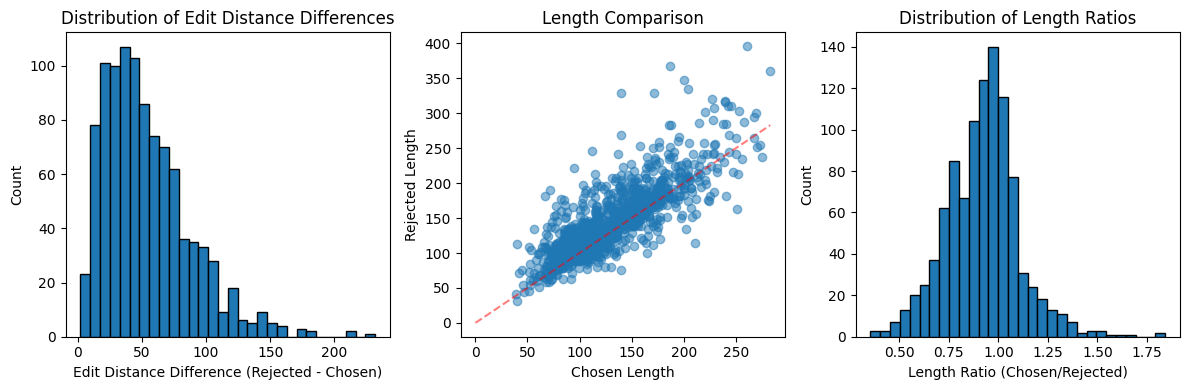


Mean edit distance difference: 53.80
Median edit distance difference: 47.00
Min/Max edit distance difference: 2/232

✅ Memory cleaned after preference dataset creation


In [38]:
# TODO: (Load and) Visualize the created dataset -- display at least 5 lines of the dataset.


# Visualize the created dataset - display 5 examples
print("\n" + "="*80)
print("SAMPLE PREFERENCE DATASET EXAMPLES:")
print("="*80)

for i in range(min(5, len(preference_dataset))):
    print(f"\nExample {i+1}:")
    print(f"Prompt: {preference_dataset[i]['prompt'][:100]}...")
    print(f"Chosen: {preference_dataset[i]['chosen']}")
    print(f"Rejected: {preference_dataset[i]['rejected']}")

    # Calculate edit distances for display
    if i < len(train_ds):
        ground_truth = train_ds[i]['tgt']
        chosen_dist = edit_distance(preference_dataset[i]['chosen'], ground_truth)
        rejected_dist = edit_distance(preference_dataset[i]['rejected'], ground_truth)
        print(f"Edit distances - Chosen: {chosen_dist}, Rejected: {rejected_dist}")
    print("-"*80)

# Analyze preference dataset quality
import matplotlib.pyplot as plt
import numpy as np

# Calculate edit distance differences for all examples
edit_distance_diffs = []
chosen_lengths = []
rejected_lengths = []

print("\nAnalyzing dataset quality...")
for i in tqdm(range(min(1000, len(preference_dataset))), desc="Analyzing"):
    # Find corresponding ground truth
    for j, train_example in enumerate(train_ds):
        if train_example['src'] == preference_dataset[i]['prompt']:
            ground_truth = train_example['tgt']
            chosen = preference_dataset[i]['chosen']
            rejected = preference_dataset[i]['rejected']

            chosen_dist = edit_distance(chosen, ground_truth)
            rejected_dist = edit_distance(rejected, ground_truth)

            edit_distance_diffs.append(rejected_dist - chosen_dist)
            chosen_lengths.append(len(chosen))
            rejected_lengths.append(len(rejected))
            break

# Plot distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(edit_distance_diffs, bins=30, edgecolor='black')
plt.xlabel('Edit Distance Difference (Rejected - Chosen)')
plt.ylabel('Count')
plt.title('Distribution of Edit Distance Differences')

plt.subplot(1, 3, 2)
plt.scatter(chosen_lengths, rejected_lengths, alpha=0.5)
plt.xlabel('Chosen Length')
plt.ylabel('Rejected Length')
plt.title('Length Comparison')
plt.plot([0, max(chosen_lengths)], [0, max(chosen_lengths)], 'r--', alpha=0.5)

plt.subplot(1, 3, 3)
length_ratios = [c/r if r > 0 else 0 for c, r in zip(chosen_lengths, rejected_lengths)]
plt.hist(length_ratios, bins=30, edgecolor='black')
plt.xlabel('Length Ratio (Chosen/Rejected)')
plt.ylabel('Count')
plt.title('Distribution of Length Ratios')

plt.tight_layout()
plt.show()

print(f"\nMean edit distance difference: {np.mean(edit_distance_diffs):.2f}")
print(f"Median edit distance difference: {np.median(edit_distance_diffs):.2f}")
print(f"Min/Max edit distance difference: {min(edit_distance_diffs)}/{max(edit_distance_diffs)}")

# Clean up GPU memory
if 'model' in globals():
    del model
torch.cuda.empty_cache()
gc.collect()
print("\n✅ Memory cleaned after preference dataset creation")


## **2.3 Run Direct Preference Optimization (DPO) [5 points]**
* Use the preference optimization dataset to further train the model through DPO, a method that leverages human-like preferences for model training.
* After running DPO, measure the BLEU score on the test set. Compare this performance to the baseline established during the SFT phase.
* Search for an optimal set of hyperparameters, such as the learning rate and number of epochs. We provide an estimated BLEU score that you should aim to achieve after one epoch. However, you may achieve a better score by finding the most suitable hyperparameters.

In [39]:
import os
from trl import DPOConfig, DPOTrainer
from transformers import AutoModelForCausalLM
from datasets import Dataset
import pandas as pd

# TODO: Run Direct Preference Optimization (DPO)



We tried learning rate 1e-6 (which is indicated by the original DPO paper), but experiments showed that BLEU score is higher when learning rate is 3e-7 compared to 1e-6. Therefore, let's use another config by setting learning rate from 1e-6 to 3e-7. we only keep the 3e-7 learning rate example here. 

In [42]:
import os
from trl import DPOConfig, DPOTrainer
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import Dataset, load_from_disk
import pandas as pd
import torch
import gc

# Set seed for reproducibility
set_seed(42)

# Clean previous models from memory
if 'model' in globals():
    del model
if 'tokenizer' in globals():
    del tokenizer
if 'base_model' in globals():
    del base_model
gc.collect()
torch.cuda.empty_cache()


print("Loading models for DPO training...")

# Load the SFT model (we'll use the padding model as it performed slightly better)
model_name = "./sft-smollm-SFTpadding-model"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float32,
    device_map="auto"
)

# Load the reference model (original base model)
base_model = AutoModelForCausalLM.from_pretrained(
    "HuggingFaceTB/SmolLM-135M",
    torch_dtype=torch.float32,
    device_map="auto"
)


# Configure tokenizer
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM-135M")
model, tokenizer = setup_tokenizer_once(model, tokenizer)
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM-135M")
base_model, tokenizer = setup_tokenizer_once(base_model, tokenizer) # CRITICAL: Setup base model with the same tokenizer configuration


assert model.config.vocab_size == base_model.config.vocab_size, "Vocab size mismatch!"
assert model.config.vocab_size == len(tokenizer), "Model-tokenizer mismatch!"



# Save Tokenizer (we forgot to save it before bc I thought configuration is easy, but now we save it so it's rigorous and reproducible)
print("\nSaving tokenizers to all our model directories...")
for model_dir in ["./sft-smollm-SFTpadding-model", "./sft-smollm-SFTpacking-model"]:
    if os.path.exists(model_dir):
        tokenizer.save_pretrained(model_dir)
        print(f"✅ Tokenizer saved to {model_dir}")

print(f"Model loaded on device: {model.device}")
print(f"Reference model loaded on device: {base_model.device}")

# Load the preference dataset
print("\nLoading preference dataset...")
preference_dataset = load_from_disk("./dpo_preference_dataset")
print(f"Preference dataset size: {len(preference_dataset)}")

# Format the dataset for DPO
def format_for_dpo(example):
    """Format dataset for DPO training"""
    # DPO expects 'prompt', 'chosen', 'rejected' fields
    # We already have these from our preference dataset creation
    return {
        "prompt": example["prompt"],
        "chosen": example["chosen"],
        "rejected": example["rejected"]
    }

# Apply formatting
dpo_dataset = preference_dataset.map(format_for_dpo)

# Split into train/validation (90/10 split)
train_size = int(0.9 * len(dpo_dataset))
dpo_train_dataset = dpo_dataset.select(range(train_size))
dpo_eval_dataset = dpo_dataset.select(range(train_size, len(dpo_dataset)))

print(f"DPO train dataset size: {len(dpo_train_dataset)}")
print(f"DPO eval dataset size: {len(dpo_eval_dataset)}")

# Configure DPO training
dpo_config = DPOConfig(
    # === OUTPUT & LOGGING ===
    output_dir="./dpo-smollm-model",
    logging_dir="./logs-dpo",

    # === TRAINING PARAMETERS ===
    num_train_epochs=1,                    # Start with 1 epoch (target BLEU ~0.50)
    learning_rate=3e-7,                    # Lower LR for DPO (fine-tuning on top of SFT)
    lr_scheduler_type="cosine",            # Smooth learning rate decay
    warmup_ratio=0.1,                      # 10% warmup

    # === DPO-SPECIFIC PARAMETERS ===
    beta=0.1,                              # DPO regularization (lower = more conservative)
    loss_type="sigmoid",                   # Standard DPO loss (alternatives: 'hinge', 'ipo')

    # === BATCH SETTINGS ===
    per_device_train_batch_size=4,         # Smaller batch for DPO (uses more memory)
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,         # Effective batch size = 4*4 = 16

    # === MIXED PRECISION ===
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),

    # === MEMORY OPTIMIZATIONS ===
    gradient_checkpointing=True,           # Enable for memory efficiency

    # === DATASET CONFIGURATION ===
    max_length=512,                        # Max sequence length for DPO
    max_prompt_length=256,                 # Max prompt length
    remove_unused_columns=False,           # Keep all columns for DPO

    # === SAVING & EVALUATION ===
    save_strategy="epoch",
    save_total_limit=2,
    eval_strategy="steps",           # Evaluate periodically
    eval_steps=100,                        # Evaluate every 500 steps

    # === LOGGING ===
    logging_steps=100,
    logging_first_step=True,
    report_to="none",

    # === OTHER ===
    seed=42,
    data_seed=42,
)

# Initialize DPO trainer
dpo_trainer = DPOTrainer(
    model=model,
    ref_model=base_model,
    args=dpo_config,
    train_dataset=dpo_train_dataset,
    eval_dataset=dpo_eval_dataset,
    processing_class=tokenizer,
)

print("\nStarting DPO training...")
print("This will take approximately 30-45 minutes...")

# Train the model
dpo_trainer.train()

print("DPO training completed!")

# Save the DPO model
dpo_trainer.save_model("./dpo-smollm-final-model")
tokenizer.save_pretrained("./dpo-smollm-final-model")
print("DPO model saved to ./dpo-smollm-final-model")

# Clean up reference model
del base_model
torch.cuda.empty_cache()

✅ Seeds set to 42 for reproducibility
Loading models for DPO training...
=== Setting up tokenizer ===
Adding [PAD] token to vocabulary...
Added 1 new tokens
Resizing model embeddings from 49154 to 49153

Adding [SEP] separator token...
Added [SEP] token, new vocab size: 49154

✓ Setup complete:
  - PAD token: '[PAD]' (ID: 49152)
  - SEP token: '[SEP]' (ID: 49153)
  - EOS token: '<|endoftext|>' (ID: 0)
  - PAD != EOS: True ✓
=== Setting up tokenizer ===
Adding [PAD] token to vocabulary...
Added 1 new tokens
Resizing model embeddings from 49152 to 49153

Adding [SEP] separator token...
Added [SEP] token, new vocab size: 49154

✓ Setup complete:
  - PAD token: '[PAD]' (ID: 49152)
  - SEP token: '[SEP]' (ID: 49153)
  - EOS token: '<|endoftext|>' (ID: 0)
  - PAD != EOS: True ✓

Saving tokenizers to all our model directories...
✅ Tokenizer saved to ./sft-smollm-SFTpadding-model
✅ Tokenizer saved to ./sft-smollm-SFTpacking-model
Model loaded on device: cuda:0
Reference model loaded on device:

Map:   0%|          | 0/19413 [00:00<?, ? examples/s]

DPO train dataset size: 17471
DPO eval dataset size: 1942


Extracting prompt in train dataset:   0%|          | 0/17471 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/17471 [00:00<?, ? examples/s]

...

Applying chat template to eval dataset:   0%|          | 0/1942 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1942 [00:00<?, ? examples/s]


Starting DPO training...
This will take approximately 30-45 minutes...


Step,Training Loss,Validation Loss,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected,Logits/chosen,Logits/rejected
100,0.755900,0.739306,1.494105,1.494785,0.503601,-0.000680,-6.965606,-38.230556,6.855970,7.227004
200,0.646500,0.637211,1.516372,1.288728,0.641461,0.227644,-6.742940,-40.291126,6.791821,7.150476
300,0.554200,0.527279,1.492647,0.972752,0.776235,0.519895,-6.980183,-43.450890,6.723928,7.073459
400,0.414200,0.427361,1.422790,0.569156,0.869342,0.853634,-7.678756,-47.486851,6.665020,7.011036
500,0.315700,0.346791,1.331420,0.130180,0.921811,1.201240,-8.592458,-51.876606,6.602801,6.954039
600,0.256400,0.289845,1.242911,-0.277050,0.943930,1.519961,-9.477550,-55.948914,6.540123,6.896781
700,0.215500,0.252574,1.169190,-0.609779,0.954733,1.778970,-10.214752,-59.276203,6.476302,6.845339
800,0.180200,0.231288,1.123994,-0.829600,0.961934,1.953594,-10.666716,-61.474407,6.420768,6.798257
900,0.177700,0.220239,1.095277,-0.957961,0.965535,2.053237,-10.953891,-62.758018,6.399230,6.783110
1000,0.169400,0.216385,1.085734,-1.002407,0.968621,2.088141,-11.049315,-63.202480,6.385710,6.771096


DPO training completed!
DPO model saved to ./dpo-smollm-final-model


In [43]:
# TODO: Evaluate model, use evaluate_model function

if 'model' in globals():
    del model

dpo_model = AutoModelForCausalLM.from_pretrained(
    "./dpo-smollm-final-model",
    torch_dtype=torch.float32,
    device_map="auto"
)

# Evaluate the DPO model
print("\nEvaluating DPO model on test set...")
dpo_bleu_score = evaluate_model(dpo_model, tokenizer, test_ds)
save_bleu_score("dpo_bleu_score", dpo_bleu_score)

# Load all scores for comparison
scores = load_bleu_scores()
baseline_bleu = scores.get("baseline_bleu", 0.0)
sft_padding_bleu = scores.get("sft_padding_bleu_score", 0.0)
dpo_bleu = scores.get("dpo_bleu_score", 0.0)

# Print comprehensive results
print("\n" + "="*70)
print("COMPLETE RESULTS COMPARISON:")
print("="*70)
print(f"Baseline BLEU (no training):     {baseline_bleu:.4f}")
print(f"SFT BLEU (padding approach):     {sft_padding_bleu:.4f}")
print(f"DPO BLEU:                        {dpo_bleu:.4f}")
print("-" * 70)
print(f"SFT improvement over baseline:   +{sft_padding_bleu - baseline_bleu:.4f}")
print(f"DPO improvement over SFT:        +{dpo_bleu - sft_padding_bleu:.4f}")
print(f"DPO improvement over baseline:   +{dpo_bleu - baseline_bleu:.4f}")
print("="*70)
print(f"\nExpected DPO BLEU score: ~0.50")




Evaluating DPO model on test set...


Evaluating:   0%|          | 0/485 [00:00<?, ?it/s]


Processed 100/485 samples... BLEU: 0.4799

Processed 200/485 samples... BLEU: 0.4807

Processed 300/485 samples... BLEU: 0.4815

Processed 400/485 samples... BLEU: 0.4801
✅ dpo_bleu_score = 0.4812 saved
✅ BLEU scores loaded from bleu_results.json

COMPLETE RESULTS COMPARISON:
Baseline BLEU (no training):     0.0513
SFT BLEU (padding approach):     0.4850
DPO BLEU:                        0.4812
----------------------------------------------------------------------
SFT improvement over baseline:   +0.4337
DPO improvement over SFT:        +-0.0038
DPO improvement over baseline:   +0.4299

Expected DPO BLEU score: ~0.50


Expected BLEU score after 1 epoch SFT + DPO is ~ 0.50.


In [44]:
# Test the DPO model on a few examples
print("\n" + "="*70)
print("SAMPLE DPO MODEL OUTPUTS:")
print("="*70)

test_examples = [
    "Fix grammatically: I likes turtles",
    "Correct the grammar: She don't know nothing about it",
    "Fix errors: The informations is not correct",
    "Improve grammar: Me and him went to store yesterday"
]

for example in test_examples:
    formatted_input = format_inference_text(example)
    inputs = tokenizer(formatted_input, return_tensors="pt", truncation=True, max_length=256)
    inputs = {k: v.to(dpo_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = dpo_model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=False)
    full_output = full_output.replace(tokenizer.eos_token, "").strip()
    if tokenizer.pad_token:
        full_output = full_output.replace(tokenizer.pad_token, "").strip()

    if "[SEP]" in full_output:
        _, correction = full_output.split("[SEP]", 1)
        print(f"\nInput: {example}")
        print(f"DPO Output: {correction.strip()}")
    else:
        print(f"\nInput: {example}")
        print(f"Full output: {full_output}")

# Clean up
del dpo_model
torch.cuda.empty_cache()
print("\n✅ DPO training and evaluation completed!")


SAMPLE DPO MODEL OUTPUTS:

Input: Fix grammatically: I likes turtles
DPO Output: I like turtles.

Input: Correct the grammar: She don't know nothing about it
DPO Output: She doesn't know nothing about it.

Input: Fix errors: The informations is not correct
DPO Output: The information is not correct. The information is not correct.

Input: Improve grammar: Me and him went to store yesterday
DPO Output: Me and him went to the store yesterday.

✅ DPO training and evaluation completed!


In [45]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import os

def load_training_history(checkpoint_path):
    """Load training history from trainer_state.json"""
    trainer_state_path = os.path.join(checkpoint_path, "trainer_state.json")
    with open(trainer_state_path, "r") as f:
        state = json.load(f)
    return state["log_history"]

def extract_losses(log_history):
    """Extract train and eval losses with steps into separate DataFrames"""
    train_data = []
    eval_data = []

    for entry in log_history:
        if "loss" in entry:
            train_data.append({
                "step": entry["step"],
                "loss": entry["loss"],
                "learning_rate": entry.get("learning_rate", 0),
                "epoch": entry.get("epoch", 0)
            })
        if "eval_loss" in entry:
            eval_data.append({
                "step": entry["step"],
                "eval_loss": entry["eval_loss"],
                "epoch": entry.get("epoch", 0)
            })

    return pd.DataFrame(train_data), pd.DataFrame(eval_data)

def plot_training_curves(train_df, eval_df, title="Training Curves", 
                        plot_loss=True, plot_lr=True, save_path=None):
    """
    Flexible plotting function
    
    Args:
        plot_loss (bool): Whether to plot loss curves
        plot_lr (bool): Whether to plot learning rate schedule
    """

    # Calculate subplot layout
    n_plots = sum([plot_loss, plot_lr])
    if n_plots == 0:
        print("❌ Error: Must plot at least one of loss or LR")
        return None

    fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 5))
    if n_plots == 1:
        axes = [axes]  # Make it iterable

    plot_idx = 0

    # Plot 1: Loss curves (if requested)
    if plot_loss:
        ax = axes[plot_idx]
        ax.plot(train_df["step"], train_df["loss"], 'b-', label='Training Loss', alpha=0.8)

        if not eval_df.empty:
            ax.plot(eval_df["step"], eval_df["eval_loss"], 'r-',
                    label='Validation Loss', marker='o', markersize=3)

            # Overfitting detection
            if len(eval_df) > 1:
                final_eval = eval_df["eval_loss"].iloc[-1]
                min_eval = eval_df["eval_loss"].min()
                if final_eval > min_eval * 1.1:
                    ax.axhline(y=min_eval, color='orange', linestyle='--', alpha=0.5,
                            label=f'Best Eval: {min_eval:.4f}')

        ax.set_xlabel('Steps')
        ax.set_ylabel('Loss')
        ax.set_title(f'{title} - Loss Curves')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plot_idx += 1

    # Plot 2: Learning rate (if requested)
    if plot_lr:
        ax = axes[plot_idx]
        if 'learning_rate' in train_df.columns and train_df['learning_rate'].max() > 0:
            ax.plot(train_df["step"], train_df["learning_rate"], 'g-', alpha=0.8)
            ax.set_xlabel('Steps')
            ax.set_ylabel('Learning Rate')
            ax.set_title(f'{title} - Learning Rate Schedule')
            ax.set_yscale('log')
        else:
            ax.text(0.5, 0.5, 'No Learning Rate Data',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title('Learning Rate Schedule')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Plot saved to {save_path}")

    plt.show()
    return fig

def plot_model_curves(checkpoint_path, title=None, plot_loss=True, plot_lr=True, save_path=None):
    """One-liner with flexible plotting options"""
    if title is None:
        title = os.path.basename(checkpoint_path.rstrip('/'))

    try:
        history = load_training_history(checkpoint_path)
        train_df, eval_df = extract_losses(history)
        return plot_training_curves(train_df, eval_df, title, plot_loss, plot_lr, save_path)
    except Exception as e:
        print(f"❌ Error plotting {checkpoint_path}: {str(e)}")
        return None

def plot_loss_comparison(checkpoint_paths, model_names=None, save_path=None):
    """Compare loss-only training curves for multiple models"""
    if model_names is None:
        model_names = [os.path.basename(path.rstrip('/')) for path in checkpoint_paths]
    plt.figure(figsize=(12, 6))

    for path, name in zip(checkpoint_paths, model_names):
        try:
            history = load_training_history(path)
            train_df, eval_df = extract_losses(history)

            plt.plot(train_df["step"], train_df["loss"],
                    label=f'{name} (Train)', alpha=0.8, linewidth=2)

            if not eval_df.empty:
                plt.plot(eval_df["step"], eval_df["eval_loss"],
                        label=f'{name} (Eval)', linestyle='--',
                        marker='o', markersize=3, alpha=0.8)
        except Exception as e:
            print(f"⚠️ Skipping {name}: {str(e)}")

    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Model Loss Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Comparison saved to {save_path}")

    plt.show()

"""
Usage Examples:

Option 1: Your preferred detailed approach:

# Load and extract
dpo_model_history = load_training_history("./dpo-smollm-model/checkpoint-1046")
dpo_model_train_df, dpo_model_eval_df = extract_losses(dpo_model_history)

# Plot with custom title
plot_training_curves(dpo_model_train_df, dpo_model_eval_df,
                    title="DPO Model", save_path="./dpo_curves.png")

Option 2: Your preferred one-liner:

# One line plotting (Full analysis (loss + LR))
plot_dpo_graph = plot_model_curves("./dpo-smollm-model/checkpoint-1046")

# With custom title and save
plot_model_curves("./dpo-smollm-model/checkpoint-1046",
                title="DPO Model", save_path="./dpo_curves.png")

# Just loss curves (cleaner for presentations)
plot_model_curves("./dpo-smollm-model/checkpoint-1046",
                title="DPO Loss Only", plot_lr=False)

# Just LR schedule (debugging convergence)
plot_model_curves("./dpo-smollm-model/checkpoint-1046",
                title="DPO LR Schedule", plot_loss=False)

Option 3: Compare all your models (just the loss curves):

# Compare all models at once
checkpoints = [
    "./sft-smollm-SFTpadding/checkpoint-2478",
    "./sft-smollm-packing/checkpoint-531",
    "./dpo-smollm-model/checkpoint-1046"
]
model_names = ["SFT Padding", "SFT Packing", "DPO"]

plot_loss_comparison(checkpoints, model_names, save_path="./all_models_comparison.png")


Recommended Workflow:

Now:

# 1. Analyze your current DPO
plot_model_curves("./dpo-smollm-model/checkpoint-1046",
                title="DPO Analysis", save_path="./dpo_current.png")

# 2. Compare all current models  
plot_loss_comparison(current_models, current_names,
                    save_path="./baseline_comparison.png")

For Each New Model:

# 3. When you train a new variant, immediately analyze it
plot_model_curves("./new-model/checkpoint-XXX",
                title="New Variant", save_path="./new_variant.png")

End of Part 3:

# 4. Final comprehensive comparison
plot_loss_comparison(all_variant_paths, all_variant_names,
                    save_path="./final_dpo_study.png")

"""

'\nUsage Examples:\n\nOption 1: Your preferred detailed approach:\n\n# Load and extract\ndpo_model_history = load_training_history("./dpo-smollm-model/checkpoint-1046")\ndpo_model_train_df, dpo_model_eval_df = extract_losses(dpo_model_history)\n\n# Plot with custom title\nplot_training_curves(dpo_model_train_df, dpo_model_eval_df,\n                    title="DPO Model", save_path="./dpo_curves.png")\n\nOption 2: Your preferred one-liner:\n\n# One line plotting (Full analysis (loss + LR))\nplot_dpo_graph = plot_model_curves("./dpo-smollm-model/checkpoint-1046")\n\n# With custom title and save\nplot_model_curves("./dpo-smollm-model/checkpoint-1046",\n                title="DPO Model", save_path="./dpo_curves.png")\n\n# Just loss curves (cleaner for presentations)\nplot_model_curves("./dpo-smollm-model/checkpoint-1046",\n                title="DPO Loss Only", plot_lr=False)\n\n# Just LR schedule (debugging convergence)\nplot_model_curves("./dpo-smollm-model/checkpoint-1046",\n            

Using most recent: ./dpo-smollm-model/checkpoint-1092
✅ Plot saved to ./dpo_current.png


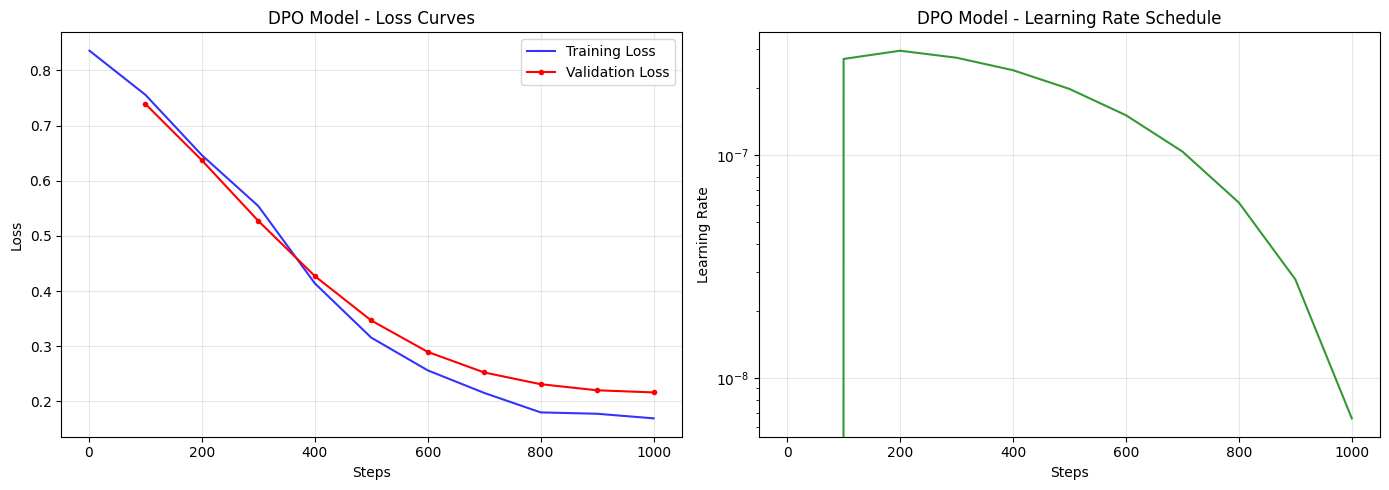

In [46]:
import glob
import os

# Find all checkpoints in the DPO model directory
checkpoint_pattern = "./dpo-smollm-model/checkpoint-*"
checkpoints = glob.glob(checkpoint_pattern)

if checkpoints:
    # Sort by modification time (most recent first)
    checkpoints.sort(key=lambda x: os.path.getmtime(x), reverse=True)
    latest_checkpoint = checkpoints[0]
    print(f"Using most recent: {latest_checkpoint}")

    # Plot the checkpoint
    plot_model_curves(latest_checkpoint,
                    title="DPO Model",
                    plot_loss=True,
                    plot_lr=True,
                    save_path="./dpo_current.png")
else:
    print("No checkpoints found in ./dpo-smollm-model/")



plt.close('all') # Close duplicate figure in jupyter notebook

# **Coding Challenge Part 3: Explore Alternative DPO Variants for Improved Model Performance [10 points]**

Consider employing a different version or variant of DPO. Your task is to:

* Choose a variant of DPO or another preference-based optimization method that could potentially enhance the model's performance.
* Describe the specific differences in this approach compared to the initial DPO method used.
* Train the model using this alternative DPO method and measure its performance on the test set using the BLEU score.
* Compare these results with the baseline performance achieved during the initial Supervised Fine-Tuning (SFT) and the first DPO implementation.
* Select a few GEC example after SFT, DPO and this DPO variant phases and compare the quality of the corrections, which one you prefer as human?
* You are allowed to make changes in the preference data annotation to improve the score, e.g. apply different metrics or methods beyond edit distance.
* Discuss the role of any changes in achieving these results. Consider potential trade-offs or limitations introduced by the new approach.


      For DPO, you first need to have an SFTed model.
      💡 Do you think it makes a difference whether the SFTed mode was trained using a padding or pad-free approach?
      👀 Take a look at the default data collator used in the DPOTrainer class and consider the implications.

In [47]:
import os
from trl import DPOConfig, DPOTrainer
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import Dataset, load_from_disk
import pandas as pd
import torch
import gc

# Set seed for reproducibility
set_seed(42)

# Clean previous models from memory
if 'model' in globals():
    del model
if 'tokenizer' in globals():
    del tokenizer
if 'base_model' in globals():
    del base_model
gc.collect()
torch.cuda.empty_cache()

print("Loading models for IPO training...")

# Load the SFT model (same as DPO)
model_name = "./sft-smollm-SFTpadding-model"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float32,
    device_map="auto"
)

# Load the reference model (same as DPO)
base_model = AutoModelForCausalLM.from_pretrained(
    "HuggingFaceTB/SmolLM-135M",
    torch_dtype=torch.float32,
    device_map="auto"
)

# Configure tokenizer (same as DPO)
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM-135M")
model, tokenizer = setup_tokenizer_once(model, tokenizer)
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM-135M")
base_model, tokenizer = setup_tokenizer_once(base_model, tokenizer) # CRITICAL: Setup base model with the same tokenizer configuration


assert model.config.vocab_size == base_model.config.vocab_size, "Vocab size mismatch!"
assert model.config.vocab_size == len(tokenizer), "Model-tokenizer mismatch!"

print(f"Model loaded on device: {model.device}")
print(f"Reference model loaded on device: {base_model.device}")

# Load the preference dataset (same as DPO)
print("\nLoading preference dataset...")
preference_dataset = load_from_disk("./dpo_preference_dataset")
print(f"Preference dataset size: {len(preference_dataset)}")

# Split into train/validation (same as DPO)
train_size = int(0.9 * len(preference_dataset))
ipo_train_dataset = preference_dataset.select(range(train_size))
ipo_eval_dataset = preference_dataset.select(range(train_size, len(preference_dataset)))

print(f"IPO train dataset size: {len(ipo_train_dataset)}")
print(f"IPO eval dataset size: {len(ipo_eval_dataset)}")

# Configure IPO training (MAIN CHANGE: loss_type="ipo")
ipo_config = DPOConfig(
    # === OUTPUT & LOGGING ===
    output_dir="./ipo-smollm-model",           # ← Changed output directory
    logging_dir="./logs-ipo",                  # ← Changed log directory

    # === TRAINING PARAMETERS (same as working DPO) ===
    num_train_epochs=1,
    learning_rate=3e-7,                        # Same LR that worked for DPO
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,

    # === IPO-SPECIFIC PARAMETERS ===
    beta=0.1,                                  # Same beta as DPO
    loss_type="ipo",                           # ← MAIN CHANGE: IPO instead of sigmoid

    # === BATCH SETTINGS (same as DPO) ===
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    # === MIXED PRECISION (same as DPO) ===
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),

    # === MEMORY OPTIMIZATIONS (same as DPO) ===
    gradient_checkpointing=True,

    # === DATASET CONFIGURATION (same as DPO) ===
    max_length=512,
    max_prompt_length=256,
    remove_unused_columns=False,

    # === SAVING & EVALUATION ===
    save_strategy="epoch",
    save_total_limit=2,
    eval_strategy="steps",                     # ← Monitor eval loss during training
    eval_steps=100,

    # === LOGGING ===
    logging_steps=100,
    logging_first_step=True,
    report_to="none",

    # === OTHER ===
    seed=42,
    data_seed=42,
)

# Initialize IPO trainer
ipo_trainer = DPOTrainer(
    model=model,
    ref_model=base_model,
    args=ipo_config,
    train_dataset=ipo_train_dataset,
    eval_dataset=ipo_eval_dataset,
    processing_class=tokenizer,
)

print("\nStarting IPO training...")
print("This will take approximately 30-45 minutes...")

# Train the model
ipo_trainer.train()

print("IPO training completed!")

# Save the IPO model
ipo_trainer.save_model("./ipo-smollm-final-model")
tokenizer.save_pretrained("./ipo-smollm-final-model")
print("IPO model and tokenizer saved to ./ipo-smollm-final-model")

# Clean up reference model
del base_model
torch.cuda.empty_cache()

✅ Seeds set to 42 for reproducibility
Loading models for IPO training...
=== Setting up tokenizer ===
Adding [PAD] token to vocabulary...
Added 1 new tokens
Resizing model embeddings from 49154 to 49153

Adding [SEP] separator token...
Added [SEP] token, new vocab size: 49154

✓ Setup complete:
  - PAD token: '[PAD]' (ID: 49152)
  - SEP token: '[SEP]' (ID: 49153)
  - EOS token: '<|endoftext|>' (ID: 0)
  - PAD != EOS: True ✓
=== Setting up tokenizer ===
Adding [PAD] token to vocabulary...
Added 1 new tokens
Resizing model embeddings from 49152 to 49153

Adding [SEP] separator token...
Added [SEP] token, new vocab size: 49154

✓ Setup complete:
  - PAD token: '[PAD]' (ID: 49152)
  - SEP token: '[SEP]' (ID: 49153)
  - EOS token: '<|endoftext|>' (ID: 0)
  - PAD != EOS: True ✓
Model loaded on device: cuda:0
Reference model loaded on device: cuda:0

Loading preference dataset...
Preference dataset size: 19413
IPO train dataset size: 17471
IPO eval dataset size: 1942


Extracting prompt in train dataset:   0%|          | 0/17471 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/17471 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/17471 [00:00<?, ? examples/s]

Extracting prompt in eval dataset:   0%|          | 0/1942 [00:00<?, ? examples/s]

Applying chat template to eval dataset:   0%|          | 0/1942 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1942 [00:00<?, ? examples/s]


Starting IPO training...
This will take approximately 30-45 minutes...


Step,Training Loss,Validation Loss,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected,Logits/chosen,Logits/rejected
100,24.095100,23.565746,0.095087,0.079269,0.673354,0.015818,-0.435835,-1.762939,6.862350,7.234209
200,23.194200,22.464903,0.098289,0.070779,0.769547,0.027510,-0.403812,-1.847831,6.808009,7.167844
300,22.223600,21.174631,0.098826,0.057162,0.853395,0.041663,-0.398449,-1.984002,6.763758,7.112332
400,20.673100,19.781008,0.096818,0.039243,0.912551,0.057575,-0.418524,-2.163193,6.729127,7.072156
500,19.171900,18.385979,0.093762,0.019542,0.940844,0.074220,-0.449082,-2.360208,6.692006,7.034036
600,17.951900,17.144026,0.090371,0.000629,0.958848,0.089743,-0.482990,-2.549340,6.651934,6.998034
700,16.740800,16.156096,0.087638,-0.015011,0.970165,0.102649,-0.510328,-2.705740,6.605588,6.960208
800,15.811500,15.486089,0.085809,-0.025910,0.974794,0.111719,-0.528616,-2.814727,6.554683,6.916032
900,15.428700,15.109797,0.084709,-0.032218,0.976852,0.116927,-0.539613,-2.877808,6.528988,6.895311
1000,15.162900,14.985819,0.084275,-0.034393,0.976852,0.118668,-0.543955,-2.899556,6.519033,6.887504


IPO training completed!
IPO model and tokenizer saved to ./ipo-smollm-final-model


In [48]:
# === SAVE TRAINING METRICS EXPLICITLY ===
print("\n📊 Saving IPO training metrics...")

# Method 1: Save the complete training history
import json
with open("./ipo_training_history.json", "w") as f:
    json.dump(ipo_trainer.state.log_history, f, indent=2)
print("✅ Training history saved to ipo_training_history.json")


📊 Saving IPO training metrics...
✅ Training history saved to ipo_training_history.json



Evaluating IPO model on test set...


Evaluating:   0%|          | 0/485 [00:00<?, ?it/s]


Processed 100/485 samples... BLEU: 0.4707

Processed 200/485 samples... BLEU: 0.4743

Processed 300/485 samples... BLEU: 0.4767

Processed 400/485 samples... BLEU: 0.4772
✅ ipo_bleu_score = 0.4789 saved
✅ BLEU scores loaded from bleu_results.json

COMPLETE RESULTS COMPARISON:
Baseline BLEU (no training):     0.0513
SFT BLEU (padding approach):     0.4850
DPO BLEU:                        0.4812
IPO BLEU:                        0.4789
----------------------------------------------------------------------
DPO improvement over SFT:        +-0.0038
IPO improvement over SFT:        +-0.0062
IPO vs DPO difference:           -0.0024
⚖️ IPO and DPO perform similarly

SAMPLE IPO MODEL OUTPUTS:

Input: Fix grammatically: I likes turtles
DPO Output: I like turtles.

Input: Correct the grammar: She don't know nothing about it
DPO Output: She doesn't know nothing about it.

Input: Fix errors: The informations is not correct
DPO Output: The informations is not correct.

Input: Improve grammar: Me an

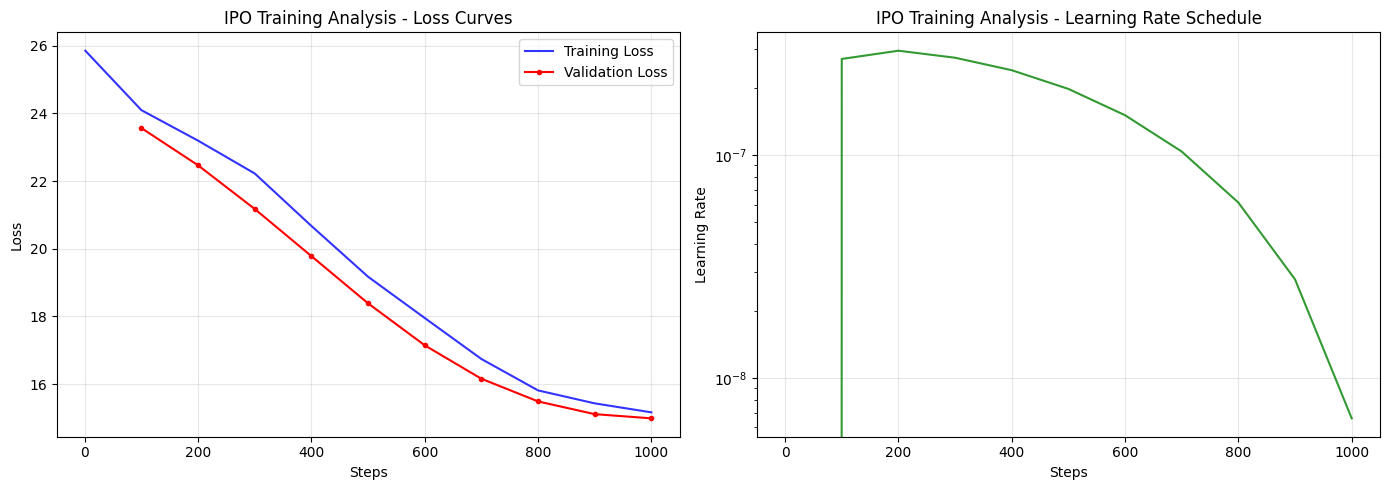

In [49]:
# Evaluate the IPO model
print("\nEvaluating IPO model on test set...")

# Load the trained model for evaluation
if 'model' in globals():
    del model

ipo_model = AutoModelForCausalLM.from_pretrained(
    "./ipo-smollm-final-model",
    torch_dtype=torch.float32,
    device_map="auto"
)

# Evaluate IPO model
ipo_bleu_score = evaluate_model(ipo_model, tokenizer, test_ds)
save_bleu_score("ipo_bleu_score", ipo_bleu_score)

# Load all scores for comparison
scores = load_bleu_scores()
baseline_bleu = scores.get("baseline_bleu", 0.0)
sft_padding_bleu = scores.get("sft_padding_bleu_score", 0.0)
dpo_bleu = scores.get("dpo_bleu_score", 0.0)
ipo_bleu = scores.get("ipo_bleu_score", 0.0)

# Print comprehensive results
print("\n" + "="*70)
print("COMPLETE RESULTS COMPARISON:")
print("="*70)
print(f"Baseline BLEU (no training):     {baseline_bleu:.4f}")
print(f"SFT BLEU (padding approach):     {sft_padding_bleu:.4f}")
print(f"DPO BLEU:                        {dpo_bleu:.4f}")
print(f"IPO BLEU:                        {ipo_bleu:.4f}")
print("-" * 70)
print(f"DPO improvement over SFT:        +{dpo_bleu - sft_padding_bleu:.4f}")
print(f"IPO improvement over SFT:        +{ipo_bleu - sft_padding_bleu:.4f}")
print(f"IPO vs DPO difference:           {ipo_bleu - dpo_bleu:+.4f}")
if ipo_bleu > dpo_bleu:
    print("🎉 IPO performs better than DPO!")
elif abs(ipo_bleu - dpo_bleu) < 0.01:
    print("⚖️ IPO and DPO perform similarly")
else:
    print("📊 DPO still performs better")
print("="*70)

# Test the IPO model on sample examples
print("\n" + "="*70)
print("SAMPLE IPO MODEL OUTPUTS:")
print("="*70)

test_examples = [
    "Fix grammatically: I likes turtles",
    "Correct the grammar: She don't know nothing about it",
    "Fix errors: The informations is not correct",
    "Improve grammar: Me and him went to store yesterday"
]

for example in test_examples:
    formatted_input = format_inference_text(example)
    inputs = tokenizer(formatted_input, return_tensors="pt", truncation=True, max_length=256)
    inputs = {k: v.to(ipo_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = ipo_model.generate(
            **inputs,
            max_new_tokens=128,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=False)
    full_output = full_output.replace(tokenizer.eos_token, "").strip()
    if tokenizer.pad_token:
        full_output = full_output.replace(tokenizer.pad_token, "").strip()

    if "[SEP]" in full_output:
        _, correction = full_output.split("[SEP]", 1)
        print(f"\nInput: {example}")
        print(f"DPO Output: {correction.strip()}")
    else:
        print(f"\nInput: {example}")
        print(f"Full output: {full_output}")

# Clean up
del ipo_model
torch.cuda.empty_cache()
print("\n✅ IPO training and evaluation completed!")

# Plot IPO results immediately
print("\n📊 Plotting IPO training curves...")

# Find the IPO checkpoint (will be the latest one)
import glob
ipo_checkpoints = glob.glob("./ipo-smollm-model/checkpoint-*")
if ipo_checkpoints:
    latest_checkpoint = max(ipo_checkpoints, key=lambda x: int(x.split('-')[-1]))
    print(f"Found IPO checkpoint: {latest_checkpoint}")

    # Plot IPO training curves
    plot_model_curves(latest_checkpoint,
                    title="IPO Training Analysis",
                    save_path="./ipo_training_curves.png")
    plt.close('all')
